In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
import matplotlib.ticker as ticker
from adjustText import adjust_text
import copy
import statistics
import pandas as pd
from itertools import chain
import sqlite3
import json
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
c=299792458

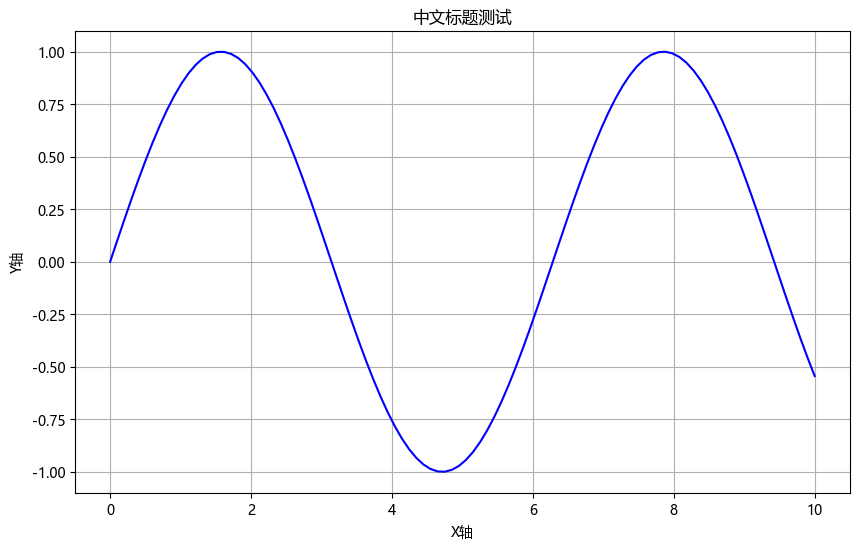

In [2]:
# 设置中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False


x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-')
plt.title('中文标题测试')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.grid(True)
plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import seaborn as sns
from collections import Counter


In [4]:
class SpectraDatabase:
    def __init__(self, db_path="spectra_data.db"):
        """初始化数据库连接"""
        self.db_path = db_path
        self.conn = None
        
    def connect(self):
        """连接数据库"""
        self.conn = sqlite3.connect(self.db_path)
        return self.conn
    
    def create_tables(self):
        """创建数据表"""
        conn = self.connect()
        cursor = conn.cursor()
        
        # 主表：光谱元数据
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS spectra_metadata (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                source TEXT, 
                molecule_name TEXT,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
            )
        ''')
        
        # 光谱数据表
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS spectra_data (
                spectrum_id INTEGER,
                velocity BLOB,  -- 存储速度数组
                flux BLOB,   -- 存储强度数组
                units TEXT,
                data_points INTEGER,
                FOREIGN KEY (spectrum_id) REFERENCES spectra_metadata(id),
                PRIMARY KEY (spectrum_id)
            )
        ''')
        
        # 标签索引表（便于搜索）
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS spectrum_tags (
                spectrum_id INTEGER,
                molecule_name TEXT
            )
        ''')
        
        conn.commit()
        print("数据库表创建完成！")
    
    def add_spectrum(self, metadata, velocity, flux):
        """添加一条光谱数据"""
        conn = self.connect()
        cursor = conn.cursor()
        
        # 插入元数据
        cursor.execute('''
            INSERT INTO spectra_metadata 
            (source, molecule_name)
            VALUES (?, ?)
        ''', (
            metadata.get('source'),
            metadata.get('molecule_name')
        ))
        
        spectrum_id = cursor.lastrowid
        
        # 插入光谱数据（将numpy数组转为二进制）
        cursor.execute('''
            INSERT INTO spectra_data 
            (spectrum_id, velocity, flux, units, data_points)
            VALUES (?, ?, ?, ?, ?)
        ''', (
            spectrum_id,
            velocity.tobytes(),  # numpy数组转二进制
            flux.tobytes(),
            metadata.get('units', 'km/s'),
            len(velocity)
        ))
        
        conn.commit()
        return spectrum_id
    
    def get_spectrum(self, spectrum_id):
        """获取完整的光谱数据"""
        conn = self.connect()
        cursor = conn.cursor()
        
        # 获取元数据
        cursor.execute('''
            SELECT * FROM spectra_metadata WHERE id = ?
        ''', (spectrum_id,))
        metadata_row = cursor.fetchone()
        
        # 获取元数据的列名
        metadata_columns = [desc[0] for desc in cursor.description]
        metadata = dict(zip(metadata_columns, metadata_row))
        
        # 获取光谱数据
        cursor.execute('''
            SELECT velocity, flux, units FROM spectra_data 
            WHERE spectrum_id = ?
        ''', (spectrum_id,))
        data_row = cursor.fetchone()
        
        if not metadata_row or not data_row:
            return None
        
        # 将二进制转回numpy数组
        velocity = np.frombuffer(data_row[0], dtype=np.float64)
        flux = np.frombuffer(data_row[1], dtype=np.float64)
        
        
        return {
            'metadata': metadata,
            'velocity': velocity,
            'flux': flux,
            'units': data_row[2]
        }
    
    def search_by_molecule(self, molecule_name):
        """按分子名称搜索"""
        conn = self.connect()
        cursor = conn.cursor()
        
        cursor.execute('''
            SELECT id, molecule_name,source
            FROM spectra_metadata 
            WHERE molecule_name LIKE ? 
            ORDER BY molecule_name
        ''', (f'%{molecule_name}%',))
        
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        return [dict(zip(columns, row)) for row in results]
    
    def get_all_metadata(self):
        """获取所有光谱的元数据（不包含光谱数据本身）"""
        conn = self.connect()
        cursor = conn.cursor()
        
        cursor.execute('''
            SELECT id, source, molecule_name, created_at
            FROM spectra_metadata
            ORDER BY molecule_name
        ''')
        
        results = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]
        return [dict(zip(columns, row)) for row in results]
    
    def close(self):
        """关闭数据库连接"""
        if self.conn:
            self.conn.close()

In [5]:
class SpectraVisualizer:
    """光谱可视化工具"""
    
    def __init__(self, db):
        self.db = db
        
    def plot_single_spectrum(self, spectrum_id, show_peaks=True, 
                           save_path=None, figsize=(12, 6)):
        """绘制单个光谱"""
        
        # 从数据库获取数据
        spectrum = self.db.get_spectrum(spectrum_id)
        
        if spectrum is None:
            print(f"未找到光谱 ID: {spectrum_id}")
            return
        
        velocity = spectrum['velocity']
        flux = spectrum['flux']
        metadata = spectrum['metadata']
        
        # 创建图形
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                      gridspec_kw={'height_ratios': [3, 1]})
        
        # 主图：光谱
        ax1.plot(velocity, flux, 'b-', linewidth=1.5, alpha=0.8, 
                label='原始数据')
        
        # 标记峰值
        if show_peaks:
            peaks = self._find_peaks(flux)
            if len(peaks) > 0:
                ax1.scatter(velocity[peaks], flux[peaks], 
                          color='red', s=50, marker='o', 
                          label=f'峰值 ({len(peaks)}个)', zorder=5)
        
        # 设置主图属性
        title = f"{metadata.get('molecule_name', '未知分子')} 光谱 (ID: {spectrum_id})"
        if metadata.get('source'):
            title += f" | 来源: {metadata['source']}"
        
        ax1.set_title(title, fontsize=14, fontweight='bold')
        ax1.set_ylabel("流量", fontsize=12)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='best')
        
        # 子图：残差（去除基线后）
        baseline = self._estimate_baseline(flux)
        residual = flux - baseline
        ax2.plot(velocity, residual, 'g-', linewidth=1, alpha=0.7)
        ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel(f"速度 ({spectrum.get('units', 'km/s')})", fontsize=12)
        ax2.set_ylabel("残差", fontsize=12)
        ax2.grid(True, alpha=0.3)
        
        # 添加统计信息
        stats_text = (f"数据点数: {len(velocity)}\n"
                     f"速度范围: {velocity[0]:.2f} 到 {velocity[-1]:.2f}\n"
                     f"流量范围: {flux.min():.3e} 到 {flux.max():.3e}\n"
                     f"信噪比: {flux.max()/np.std(flux):.1f}" 
                     if np.std(flux) > 0 else "信噪比: N/A")
        
        ax1.text(0.02, 0.98, stats_text,
                transform=ax1.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_multiple_spectra(self, spectrum_ids, normalize=False, 
                            save_path=None, figsize=(14, 8)):
        """绘制多个光谱（叠加显示）"""
        
        fig, ax = plt.subplots(figsize=figsize)
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(spectrum_ids)))
        
        for idx, spectrum_id in enumerate(spectrum_ids):
            spectrum = self.db.get_spectrum(spectrum_id)
            
            if spectrum is None:
                print(f"未找到光谱 ID: {spectrum_id}")
                continue
            
            velocity = spectrum['velocity']
            flux = spectrum['flux']
            metadata = spectrum['metadata']
            
            # 归一化处理
            if normalize:
                flux = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
            
            # 绘制
            label = f"{metadata.get('molecule_name', '未知')} (ID: {spectrum_id})"
            ax.plot(velocity, flux, color=colors[idx], linewidth=1.5, 
                   alpha=0.7, label=label)
        
        ax.set_xlabel(f"速度 (km/s)", fontsize=12)
        ax.set_ylabel("流量" + (" (归一化)" if normalize else ""), fontsize=12)
        ax.set_title(f"多个光谱比较 (共 {len(spectrum_ids)} 个)", 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=10)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_by_molecule(self, molecule_name, max_spectra=10, 
                        save_path=None, figsize=(15, 10)):
        """绘制特定分子的多个光谱"""
        
        # 搜索该分子的所有光谱
        results = self.db.search_by_molecule(molecule_name)
        
        if not results:
            print(f"未找到分子 {molecule_name} 的光谱")
            return
        
        print(f"找到 {len(results)} 个 {molecule_name} 光谱")
        
        # 限制显示数量
        display_count = min(len(results), max_spectra)
        spectrum_ids = [r['id'] for r in results[:display_count]]
        
        # 创建图形
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        axes = axes.flatten()
        
        # 1. 所有光谱叠加
        for i, spectrum_id in enumerate(spectrum_ids):
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                velocity = spectrum['velocity']
                flux = spectrum['flux']
                flux_norm = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
                axes[0].plot(velocity, flux_norm, linewidth=1, alpha=0.6)
        
        axes[0].set_title(f"{molecule_name} 光谱 (所有叠加)")
        axes[0].set_xlabel("速度 (km/s)")
        axes[0].set_ylabel("归一化流量")
        axes[0].grid(True, alpha=0.3)
        
        # 2. 平均光谱
        all_fluxes = []
        for spectrum_id in spectrum_ids:
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                flux = spectrum['flux']
                flux_norm = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
                all_fluxes.append(flux_norm)
        
        if all_fluxes:
            avg_flux = np.mean(all_fluxes, axis=0)
            std_flux = np.std(all_fluxes, axis=0)
            
            axes[1].plot(velocity, avg_flux, 'b-', linewidth=2, label='平均')
            axes[1].fill_between(velocity, avg_flux - std_flux, avg_flux + std_flux, 
                               alpha=0.3, color='blue', label='标准差')
            axes[1].set_title(f"{molecule_name} 平均光谱")
            axes[1].set_xlabel("速度 (km/s)")
            axes[1].set_ylabel("归一化流量")
            axes[1].grid(True, alpha=0.3)
            axes[1].legend()
        
        # 3. 最大值光谱
        max_spectrum_id = spectrum_ids[0]
        max_amplitude = 0
        for spectrum_id in spectrum_ids:
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                flux = spectrum['flux']
                if np.max(flux) > max_amplitude:
                    max_amplitude = np.max(flux)
                    max_spectrum_id = spectrum_id
        
        spectrum = self.db.get_spectrum(max_spectrum_id)
        if spectrum:
            axes[2].plot(spectrum['velocity'], spectrum['flux'], 'r-', linewidth=2)
            axes[2].set_title(f"{molecule_name} 最强光谱 (ID: {max_spectrum_id})")
            axes[2].set_xlabel("速度 (km/s)")
            axes[2].set_ylabel("流量")
            axes[2].grid(True, alpha=0.3)
        
        # 4. 信噪比分布
        snr_values = []
        for spectrum_id in spectrum_ids:
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                flux = spectrum['flux']
                snr = flux.max() / np.std(flux) if np.std(flux) > 0 else 0
                snr_values.append(snr)
        
        axes[3].hist(snr_values, bins=10, alpha=0.7, color='green', edgecolor='black')
        axes[3].set_title(f"{molecule_name} 信噪比分布")
        axes[3].set_xlabel("信噪比")
        axes[3].set_ylabel("光谱数量")
        axes[3].grid(True, alpha=0.3)
        
        plt.suptitle(f"{molecule_name} 分子光谱分析", fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def plot_database_summary(self, save_path=None, figsize=(16, 12)):
        """绘制数据库整体概览"""
        
        # 获取所有光谱的元数据
        all_spectra = self.db.get_all_metadata()
        
        if not all_spectra:
            print("数据库为空")
            return
        
        print(f"数据库中有 {len(all_spectra)} 条光谱")
        
        # 创建图形
        fig = plt.figure(figsize=figsize)
        gs = GridSpec(3, 3, figure=fig)
        
        # 1. 分子分布 (条形图)
        ax1 = fig.add_subplot(gs[0, 0])
        molecules = [s.get('molecule_name', '未知') for s in all_spectra]
        mol_counter = Counter(molecules)
        
        mol_names, mol_counts = zip(*mol_counter.most_common(10))  # 显示前10个
        bars = ax1.bar(range(len(mol_names)), mol_counts, alpha=0.7, color='skyblue')
        ax1.set_title("分子分布 (前10)", fontsize=12, fontweight='bold')
        ax1.set_ylabel("光谱数量", fontsize=10)
        ax1.set_xticks(range(len(mol_names)))
        ax1.set_xticklabels(mol_names, rotation=45, ha='right', fontsize=9)
        
        # 在条形上添加数量
        for bar, count in zip(bars, mol_counts):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   str(count), ha='center', va='bottom', fontsize=8)
        
        # 2. 来源分布 (饼图)
        ax2 = fig.add_subplot(gs[0, 1])
        sources = [s.get('source', '未知') for s in all_spectra]
        src_counter = Counter(sources)
        
        src_names, src_counts = zip(*src_counter.most_common(8))
        wedges, texts, autotexts = ax2.pie(src_counts, labels=src_names, autopct='%1.1f%%',
                                          startangle=90, textprops={'fontsize': 9})
        ax2.set_title("来源分布", fontsize=12, fontweight='bold')
        
        # 3. 数据点数分布
        ax3 = fig.add_subplot(gs[0, 2])
        data_points = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                data_points.append(len(spectrum['velocity']))
        
        ax3.hist(data_points, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        ax3.set_title("数据点数分布", fontsize=12, fontweight='bold')
        ax3.set_xlabel("数据点数", fontsize=10)
        ax3.set_ylabel("光谱数量", fontsize=10)
        ax3.grid(True, alpha=0.3)
        
        # 4. 信噪比分布
        ax4 = fig.add_subplot(gs[1, 0])
        snr_values = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                flux = spectrum['flux']
                snr = flux.max() / np.std(flux) if np.std(flux) > 0 else 0
                snr_values.append(snr)
        
        ax4.hist(snr_values, bins=20, alpha=0.7, color='salmon', edgecolor='black')
        ax4.set_title("信噪比分布", fontsize=12, fontweight='bold')
        ax4.set_xlabel("信噪比", fontsize=10)
        ax4.set_ylabel("光谱数量", fontsize=10)
        ax4.grid(True, alpha=0.3)
        
        # 5. 平均流量分布
        ax5 = fig.add_subplot(gs[1, 1])
        mean_flux_values = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                flux = spectrum['flux']
                mean_flux_values.append(np.mean(flux))
        
        ax5.hist(mean_flux_values, bins=20, alpha=0.7, color='gold', edgecolor='black')
        ax5.set_title("平均流量分布", fontsize=12, fontweight='bold')
        ax5.set_xlabel("平均流量", fontsize=10)
        ax5.set_ylabel("光谱数量", fontsize=10)
        ax5.grid(True, alpha=0.3)
        
        # 6. 峰值数量分布
        ax6 = fig.add_subplot(gs[1, 2])
        peak_counts = []
        for spec in all_spectra:
            spectrum = self.db.get_spectrum(spec['id'])
            if spectrum:
                flux = spectrum['flux']
                peaks = self._find_peaks(flux, height=np.std(flux)*2)
                peak_counts.append(len(peaks))
        
        unique, counts = np.unique(peak_counts, return_counts=True)
        ax6.bar(unique, counts, alpha=0.7, color='purple', edgecolor='black')
        ax6.set_title("峰值数量分布", fontsize=12, fontweight='bold')
        ax6.set_xlabel("峰值数量", fontsize=10)
        ax6.set_ylabel("光谱数量", fontsize=10)
        ax6.grid(True, alpha=0.3)
        
        # 7. 随机抽样显示4个光谱
        ax7 = fig.add_subplot(gs[2, :])
        
        # 随机选择4个光谱
        import random
        sample_ids = random.sample([s['id'] for s in all_spectra], min(4, len(all_spectra)))
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(sample_ids)))
        
        for i, spectrum_id in enumerate(sample_ids):
            spectrum = self.db.get_spectrum(spectrum_id)
            if spectrum:
                velocity = spectrum['velocity']
                flux = spectrum['flux']
                flux_norm = (flux - flux.min()) / (flux.max() - flux.min() + 1e-10)
                
                label = f"ID {spectrum_id}: {spectrum['metadata'].get('molecule_name', '未知')}"
                ax7.plot(velocity, flux_norm + i*0.3, color=colors[i], 
                        linewidth=1.5, label=label, alpha=0.8)
        
        ax7.set_title("随机抽样光谱 (归一化并垂直偏移)", fontsize=12, fontweight='bold')
        ax7.set_xlabel("速度 (km/s)", fontsize=10)
        ax7.set_ylabel("归一化流量 (偏移后)", fontsize=10)
        ax7.legend(loc='upper right', fontsize=9)
        ax7.grid(True, alpha=0.3)
        
        plt.suptitle(f"光谱数据库概览 (共 {len(all_spectra)} 条光谱)", 
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"图表已保存到: {save_path}")
        
        plt.show()
        
        return fig
    
    def _find_peaks(self, flux, height=None, distance=10):
        """寻找峰值点"""
        from scipy.signal import find_peaks
        
        if height is None:
            height = np.std(flux) * 2
        
        peaks, _ = find_peaks(flux, height=height, distance=distance)
        return peaks
    
    def _estimate_baseline(self, flux, n_baseline=5):
        """估计基线"""
        if len(flux) <= 2 * n_baseline:
            return np.mean(flux)
        
        baseline = np.mean(np.concatenate([flux[:n_baseline], flux[-n_baseline:]]))
        return baseline

In [6]:
def interactive_visualization(db):
    """交互式可视化界面"""
    
    visualizer = SpectraVisualizer(db)
    
    while True:
        print("\n" + "=" * 50)
        print("          光谱数据可视化工具")
        print("=" * 50)
        print("1. 📊 查看数据库概览")
        print("2. 📈 查看单个光谱")
        print("3. 🔍 按分子查看光谱")
        print("4. 📉 比较多个光谱")
        print("5. 🎲 随机查看光谱")
        print("6. 📋 生成报告")
        print("7. ❌ 退出")
        print("-" * 50)
        
        choice = input("请选择操作 (1-7): ")
        
        if choice == "1":
            # 数据库概览
            print("\n生成数据库概览图表...")
            save = input("是否保存图表？(输入文件名或留空): ")
            visualizer.plot_database_summary(save_path=save if save else None)
        
        elif choice == "2":
            # 单个光谱
            spectrum_id = int(input("输入光谱ID: "))
            show_peaks = input("显示峰值吗？(y/n): ").lower() == 'y'
            save = input("是否保存图表？(输入文件名或留空): ")
            
            visualizer.plot_single_spectrum(spectrum_id, show_peaks=show_peaks,
                                          save_path=save if save else None)
        
        elif choice == "3":
            # 按分子查看
            molecule = input("输入分子名 (如 CO, HCN): ")
            max_display = input("最大显示数量 (默认10): ")
            max_display = int(max_display) if max_display else 10
            
            save = input("是否保存图表？(输入文件名或留空): ")
            
            visualizer.plot_by_molecule(molecule, max_spectra=max_display,
                                      save_path=save if save else None)
        
        elif choice == "4":
            # 比较多个光谱
            print("\n输入要比较的光谱ID，用逗号分隔")
            ids_input = input("例如: 1,3,5,7\n光谱ID: ")
            
            try:
                spectrum_ids = [int(id.strip()) for id in ids_input.split(',')]
                normalize = input("归一化吗？(y/n): ").lower() == 'y'
                save = input("是否保存图表？(输入文件名或留空): ")
                
                visualizer.plot_multiple_spectra(spectrum_ids, normalize=normalize,
                                               save_path=save if save else None)
            except:
                print("输入格式错误")
        
        elif choice == "5":
            # 随机查看
            import random
            
            all_spectra = db.get_all_metadata()
            if all_spectra:
                random_id = random.choice([s['id'] for s in all_spectra])
                print(f"随机选择光谱 ID: {random_id}")
                
                spectrum = db.get_spectrum(random_id)
                if spectrum:
                    print(f"  分子: {spectrum['metadata'].get('molecule_name', '未知')}")
                    print(f"  来源: {spectrum['metadata'].get('source', '未知')}")
                    print(f"  数据点数: {len(spectrum['velocity'])}")
                
                show = input("显示这个光谱吗？(y/n): ")
                if show.lower() == 'y':
                    visualizer.plot_single_spectrum(random_id)
            else:
                print("数据库为空")
        
        elif choice == "6":
            # 生成报告
            generate_report(db, visualizer)
        
        elif choice == "7":
            print("再见！")
            break
        
        else:
            print("无效选择")
        
        input("\n按Enter键继续...")

def generate_report(db, visualizer):
    """生成可视化报告"""
    
    import os
    from datetime import datetime
    
    # 创建报告目录
    report_dir = f"spectra_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    os.makedirs(report_dir, exist_ok=True)
    
    print(f"\n生成报告到目录: {report_dir}")
    
    # 获取所有数据
    all_spectra = db.get_all_metadata()
    
    if not all_spectra:
        print("数据库为空")
        return
    
    # 1. 数据库概览图
    print("1. 生成数据库概览图...")
    visualizer.plot_database_summary(save_path=f"{report_dir}/01_database_summary.png")
    
    # 2. 按分子统计图
    print("2. 生成分子统计图...")
    
    # 获取所有分子
    molecules = list(set([s.get('molecule_name', '未知') for s in all_spectra]))
    
    # 为每个主要分子生成图表（最多5个）
    for i, molecule in enumerate(molecules[:5]):
        print(f"  生成 {molecule} 分子图...")
        try:
            visualizer.plot_by_molecule(molecule, max_spectra=10,
                                      save_path=f"{report_dir}/02_molecule_{molecule}.png")
        except:
            print(f"  生成 {molecule} 图表时出错")
    
    # 3. 随机选择5个光谱的详细图
    print("3. 生成随机光谱详细图...")
    import random
    random_ids = random.sample([s['id'] for s in all_spectra], min(5, len(all_spectra)))
    
    for i, spectrum_id in enumerate(random_ids):
        print(f"  生成光谱 ID {spectrum_id} 图...")
        try:
            visualizer.plot_single_spectrum(spectrum_id, show_peaks=True,
                                          save_path=f"{report_dir}/03_spectrum_{spectrum_id}.png")
        except:
            print(f"  生成光谱 {spectrum_id} 图表时出错")
    
    # 4. 生成文本报告
    print("4. 生成文本报告...")
    
    with open(f"{report_dir}/report_summary.txt", 'w', encoding='utf-8') as f:
        f.write("光谱数据库分析报告\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"数据库文件: {db.db_path}\n")
        f.write(f"总光谱数量: {len(all_spectra)}\n\n")
        
        # 分子统计
        from collections import Counter
        mol_counter = Counter([s.get('molecule_name', '未知') for s in all_spectra])
        
        f.write("分子分布:\n")
        for mol, count in mol_counter.most_common():
            f.write(f"  {mol}: {count} 条 ({count/len(all_spectra)*100:.1f}%)\n")
        
        f.write("\n")
        
        # 来源统计
        src_counter = Counter([s.get('source', '未知') for s in all_spectra])
        
        f.write("来源分布:\n")
        for src, count in src_counter.most_common():
            f.write(f"  {src}: {count} 条\n")
        
        f.write("\n")
        
        # 数据统计
        data_points = []
        snr_values = []
        
        for spec in all_spectra:
            spectrum = db.get_spectrum(spec['id'])
            if spectrum:
                data_points.append(len(spectrum['velocity']))
                flux = spectrum['flux']
                snr = flux.max() / np.std(flux) if np.std(flux) > 0 else 0
                snr_values.append(snr)
        
        if data_points:
            f.write("数据统计:\n")
            f.write(f"  平均数据点数: {np.mean(data_points):.1f}\n")
            f.write(f"  最小数据点数: {np.min(data_points)}\n")
            f.write(f"  最大数据点数: {np.max(data_points)}\n")
        
        if snr_values:
            f.write(f"\n  平均信噪比: {np.mean(snr_values):.1f}\n")
            f.write(f"  最小信噪比: {np.min(snr_values):.1f}\n")
            f.write(f"  最大信噪比: {np.max(snr_values):.1f}\n")
    
    print(f"\n报告生成完成！所有文件保存在: {report_dir}")
    print(f"包含:")
    print(f"  - 数据库概览图")
    print(f"  - 分子分析图")
    print(f"  - 随机光谱详细图")
    print(f"  - 文本统计报告")


          光谱数据可视化工具
1. 📊 查看数据库概览
2. 📈 查看单个光谱
3. 🔍 按分子查看光谱
4. 📉 比较多个光谱
5. 🎲 随机查看光谱
6. 📋 生成报告
7. ❌ 退出
--------------------------------------------------
请选择操作 (1-7): 4

输入要比较的光谱ID，用逗号分隔
例如: 1,3,5,7
光谱ID: 7
归一化吗？(y/n): 
是否保存图表？(输入文件名或留空): 


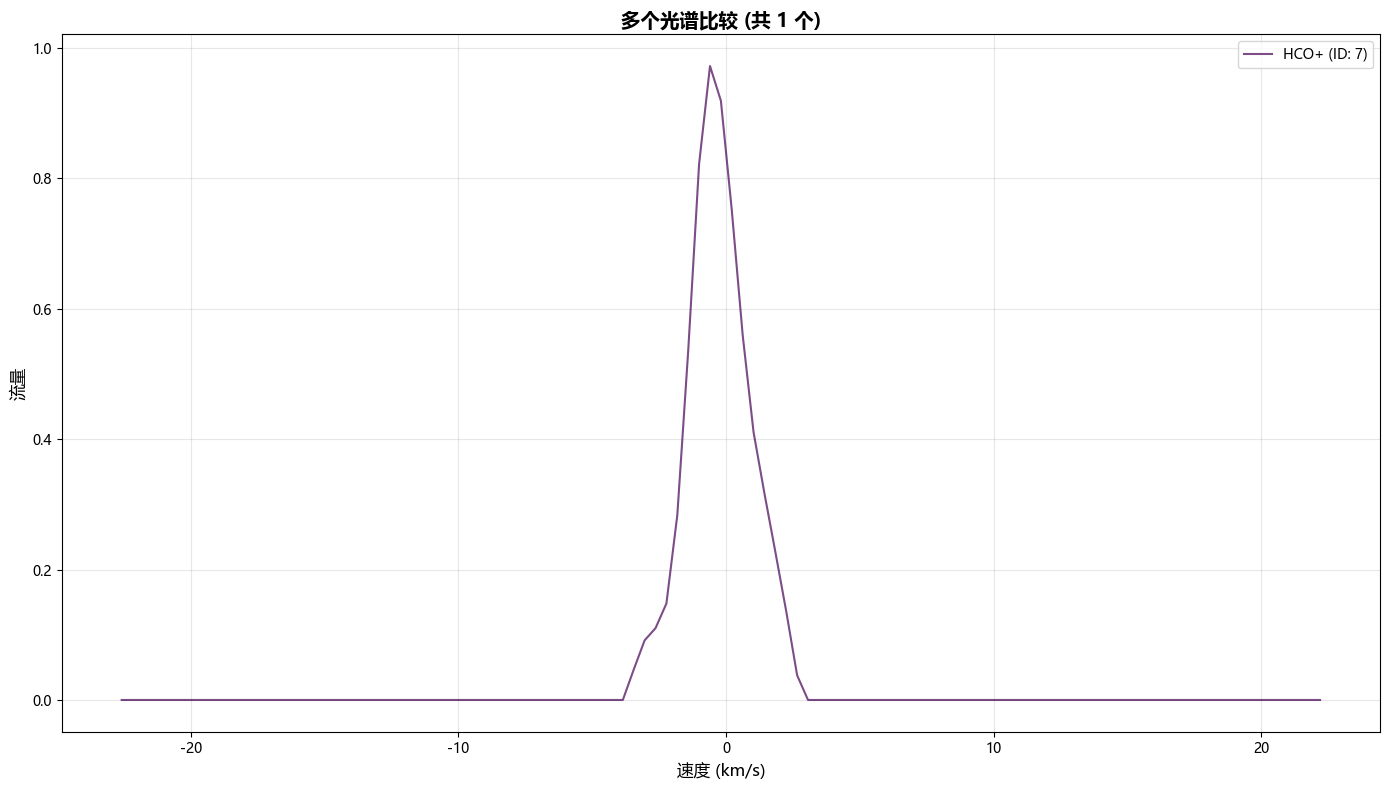


按Enter键继续...

          光谱数据可视化工具
1. 📊 查看数据库概览
2. 📈 查看单个光谱
3. 🔍 按分子查看光谱
4. 📉 比较多个光谱
5. 🎲 随机查看光谱
6. 📋 生成报告
7. ❌ 退出
--------------------------------------------------
请选择操作 (1-7): 3
输入分子名 (如 CO, HCN): SO2
最大显示数量 (默认10): 50
是否保存图表？(输入文件名或留空): 
找到 131 个 SO2 光谱


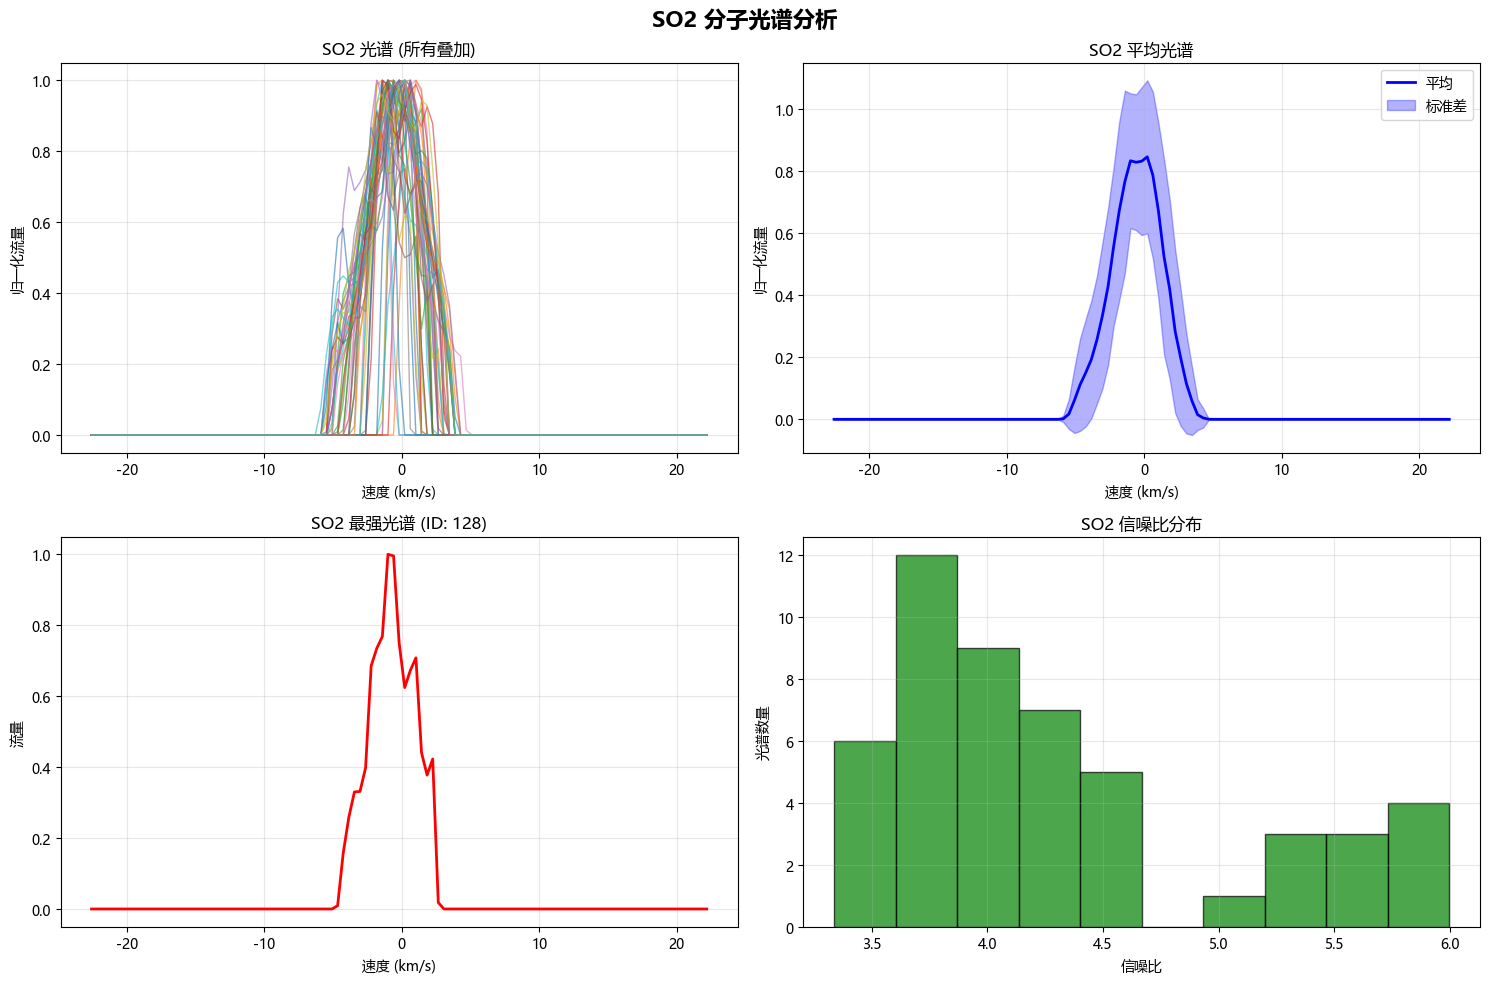


按Enter键继续...

          光谱数据可视化工具
1. 📊 查看数据库概览
2. 📈 查看单个光谱
3. 🔍 按分子查看光谱
4. 📉 比较多个光谱
5. 🎲 随机查看光谱
6. 📋 生成报告
7. ❌ 退出
--------------------------------------------------
请选择操作 (1-7): 8
无效选择

按Enter键继续...

          光谱数据可视化工具
1. 📊 查看数据库概览
2. 📈 查看单个光谱
3. 🔍 按分子查看光谱
4. 📉 比较多个光谱
5. 🎲 随机查看光谱
6. 📋 生成报告
7. ❌ 退出
--------------------------------------------------
请选择操作 (1-7): 7
再见！


In [31]:
db = SpectraDatabase("spectra_no_noise_normalize_all_source.db")
interactive_visualization(db)

In [8]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE,MDS, Isomap,LocallyLinearEmbedding,SpectralEmbedding
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [9]:
# 颜色区分分子
color_map = {'33SO2':'#000000', '13CH3OH???':'#FF0000', 'CO':'#00FF00', 
             'HC15N':'#0000FF', 'CH3OH':'#FFFF00','H13CO+':'#00FFFF','SO+':'#FF00FF',
             'SiO':'#8470FF', 'SO2':'#FFC0CB', 'HCO+':'#FFA07A', 'SO':'#A9A9A9', 'CH3OCH3':'#8B0000',
             '34SO2':'#ADD8E6', 't-HCOOH':'#90EE90', 'HC3N':'#D8BFD8'}

# 形状列表
marker_map = {'Lm07':'o','Lm10': '^','Ll10': 'X','Lh03': 'p','Lh05': '*','Lh07': 'h', 'Lh08':'d','Lh09': 'D','Lh10': 'v'}

# # 源的演化
# group_classified = {'Lm07':'PE','Lm10': 'S','Ll10': 'S','Lh03': 'S','Lh05': 'PE','Lh07': 'P', 'Lh08':'PE','Lh09': 'SE','Lh10': 'S'}

In [10]:
# 颜色区分源
color_map_sources=  {
                     'Lh01': '#1f77b4', 'Lh02': '#ff7f0e', 'Lh03': '#2ca02c', 'Lh04': '#d62728',
                     'Lh05': '#9467bd', 'Lh06': '#8c564b', 'Lh07': '#e377c2', 'Lh08': '#7f7f7f',
                     'Lh09': '#bcbd22', 'Lh10': '#17becf', 'Lm01': '#aec7e8', 'Lm02': '#ffbb78',
                     'Lm03': '#98df8a', 'Lm04': '#ff9896', 'Lm05': '#c5b0d5', 'Lm06': '#c49c94',
                     'Lm07': '#f7b6d2', 'Lm08': '#c7c7c7', 'Lm09': '#dbdb8d', 'Lm10': '#9edae5',
                     'Ll01': '#393b79', 'Ll02': '#5254a3', 'Ll03': '#6b6ecf', 'Ll04': '#9c9ede',
                     'Ll05': '#637939', 'Ll06': '#8ca252', 'Ll07': '#b5cf6b', 'Ll08': '#cedb9c',
                     'Ll09': '#8c6d31', 'Ll10': '#bd9e39'
                    }


In [11]:
# print(group_classified['Lm07'])

In [12]:
# 1. 连接数据库
conn = sqlite3.connect("spectra_no_noise_normalize_all_source.db")
cursor = conn.cursor()

# 2. 提取数据
cursor.execute("""
    SELECT source, molecule_name, flux 
    FROM spectra_metadata sm 
    JOIN spectra_data sd ON sm.id = sd.spectrum_id
""")

rows = cursor.fetchall()
conn.close()

if not rows:
    print("数据库中没有找到数据！")


# 3. 整理数据
sources, molecules, fluxes = zip(*rows)

# 4. 创建流量矩阵
flux_matrix = np.vstack([np.frombuffer(f, dtype=np.float64) for f in fluxes])
print(f"流量矩阵形状: {flux_matrix.shape}")

流量矩阵形状: (281, 111)


In [13]:
# ------------------------------检查数据--------------------------------
# flux_matrix 流量矩阵 （200，111） 200条长度为111的光谱 类型：numpy.ndarray
# sources 源名字 200 200个源名称 类型：tuple
# molecules 分子名称 200 200个分子名称 类型：tuple

print(flux_matrix.shape)
print(len(sources))
print(molecules)
print(sources)
print(type(sources))
print(type(flux_matrix))

(281, 111)
281
('SO', 'CO', 'SO', 'HCO+', 'CO', 'SO', 'HCO+', 'CO', 'HCO+', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'CO', 'HCO+', 'CO', 'HCO+', 'SO', 'CO', 'SO', 'HCO+', 'SO', 'CO', 'SO', 'HCO+', 'SO', 'SO2', 'CO', 'SO', 'SO2', 'H13CO+', 'HCO+', 'SO2', 'SO2', 'SO2', 'SO2', 'CO', 'SO', 'HCO+', 'SO', 'CO', 'SO', 'HCO+', 'SO2', 'CO', 'HCO+', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'CH3OH', 'SO', 'CO', 'SO', 'HCO+', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'SO', 'SO2', 'CO', 'CH3OH', 'SO', 'SO2', 'H13CO+', 'SiO', 'HCO+', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'CH3OH', 'SO2', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'CH3OH', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', 'SO', '34SO2', 'SO2', 'CO', 'SO', 'SO2', 'H13CO+', 'SiO', 'HCO+', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO', 'CO', 'SO', 'H13CO+', 'HCO+', '

In [14]:
# 降维
spec=SpectralEmbedding(n_components=4)
digits_spec=spec.fit_transform(flux_matrix)

In [15]:
# 聚类
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(digits_spec)

D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
D:\anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


# 检查结果

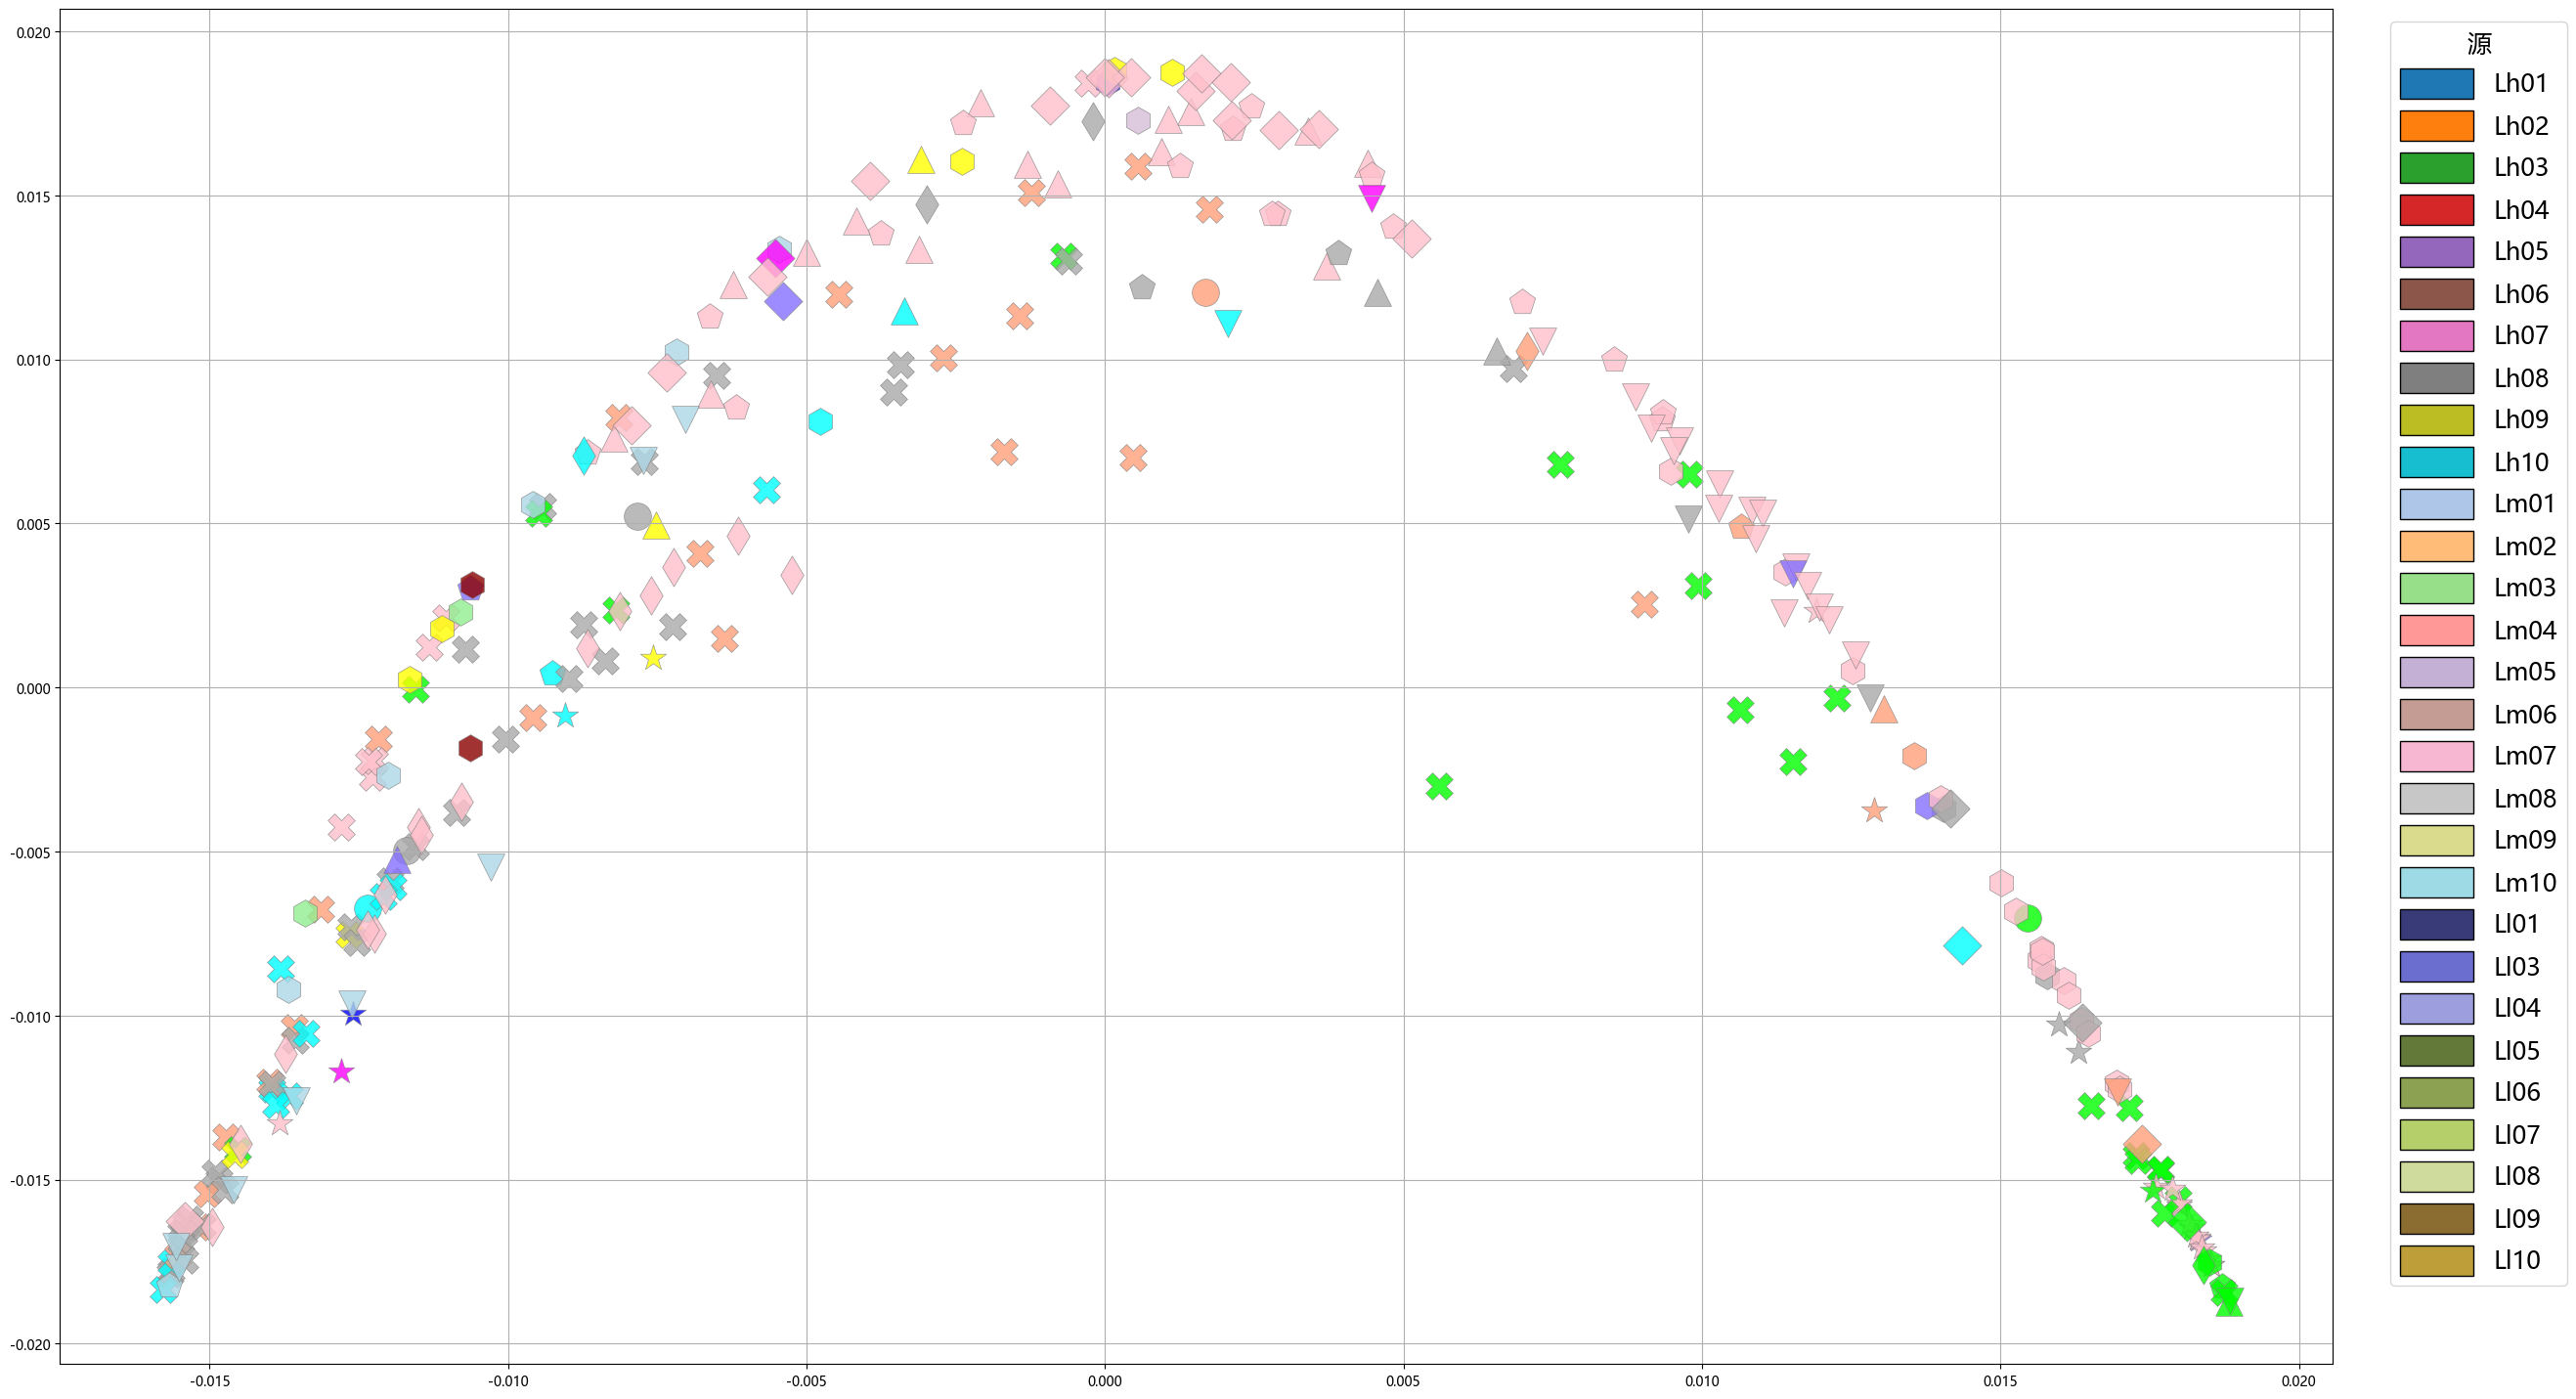

In [16]:
unique_sources = list(set(sources))
unique_molecules = list(set(molecules))

# 分子图例（颜色）
legend_elements_mol = []
for mol in color_map.keys():
    if mol in unique_molecules:
        legend_elements_mol.append(
            Patch(facecolor=color_map[mol], edgecolor='black', label=mol)
        )

# 源图例（形状）
legend_elements_src = []
for src in marker_map.keys():
    if src in unique_sources:
        # 使用Line2D创建形状图例，颜色设为黑色以便清晰显示形状
        legend_elements_src.append(
            Line2D([0], [0], marker=marker_map[src], color='w', label=src,
                   markerfacecolor='black', markersize=15, markeredgecolor='black', linewidth=0)
        )

# 源图例（颜色）
legend_elements_src_color = []
for src in color_map_sources.keys():
    if src in unique_sources:
        # 使用Line2D创建形状图例，颜色设为黑色以便清晰显示形状
        legend_elements_src_color.append(
           Patch(facecolor=color_map_sources[src], edgecolor='black', label=src)
        )
        
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()

# 绘制散点 
for (x, y, z, k), src, mol in zip(digits_spec, sources, molecules):
    if mol != 'O2':
        color = color_map.get(mol, '#808080')
        #color = color_map_sources.get(src) 
        marker = marker_map.get(src,"X") 

        plt.scatter(x, y, c=color, marker=marker,
                    s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)

# 添加图例 
# legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
#                     loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
#                     handleheight=1.5, title_fontsize=18, fontsize=18)
# ax.add_artist(legend1)

# legend2 = ax.legend(handles=legend_elements_src, title='源', 
#                     loc='upper left', bbox_to_anchor=(1.02, 0.55), handlelength=5,
#                     handleheight=5, title_fontsize=18, fontsize=18, 
#                     labelspacing=0, markerscale=2.0)

legend1 = ax.legend(handles=legend_elements_src_color, title='源', 
                    loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
                    handleheight=1.5, title_fontsize=18, fontsize=18)


# plt.tight_layout(rect=[0, 0, 0.85, 1])  # 添加布局调整
#plt.savefig('C:\\Users\\zyx\\Desktop\\Spectral with Machine Learning\\code\\picture\\all_sources_SO2.png', dpi=600, bbox_inches='tight')
#plt.xlim(-0.02,0.02)
plt.show()



In [17]:
# # 假设 labels 是 KMeans 聚类得到的 0~5 的整数
# unique_labels = np.unique(labels)          # [0,1,2,3,4,5]
# n_colors = len(unique_labels)               # 6

# # 设置边界：每个整数 i 对应区间 [i-0.5, i+0.5]
# bounds = np.arange(n_colors + 1) - 0.5      # [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

# # 使用 BoundaryNorm，数据值落在哪个区间就用哪种颜色
# norm = BoundaryNorm(bounds, plt.cm.Set1.N)  # 第二个参数是颜色数，直接使用 colormap 的颜色数

# plt.figure(figsize=(30, 18))
# plt.grid()
# plt.scatter(digits_spec[:, 0], digits_spec[:, 1],
#             c=labels, cmap='Set1', norm=norm,
#             s=400, alpha=0.8, edgecolors='grey', linewidth=0.5)

# # 创建颜色条，刻度设置为实际的标签值
# cbar = plt.colorbar(ticks=unique_labels)
# cbar.ax.set_yticklabels(unique_labels)       # 让刻度显示为 0,1,2,3,4,5
# cbar.set_label('Cluster Label')

# plt.title('Spectral Embedding projection with Spectral Clustering labels')
# plt.show()

In [18]:
# for i,((x, y), src, mol) in enumerate(zip(digits_spec, sources, molecules)):
#     if mol=='SO2':
#         if x<-0.01:
#             plt.plot(flux_matrix[i],color='red')
#         if -0.01<x<0.01:
#             plt.plot(flux_matrix[i],color='green')
#         if x>0.01:
#             plt.plot(flux_matrix[i],color='blue')
            
# # plt.ylim(0,0.2)


In [19]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
# for i,((x, y), src, mol) in enumerate(zip(digits_spec, sources, molecules)):
#     if -0.02<x<-0.01:
#         if mol=='SO2':
#             axes[0].plot(flux_matrix[i],color='blue',label=src)
#         if mol!='SO2':
#             axes[1].plot(flux_matrix[i],color='green')

# axes[0].legend(ncol=2)
# plt.show()

## 下面是加入了分子/源其它信息的结果

### 读取信息

In [20]:
# -----------------------读取分子信息--------------------------------

path_molecular='C:\\Users\\zyx\\Desktop\\Spectral with Machine Learning\\data\\molecular_data.txt'
import re
import pandas as pd
from io import StringIO

# 1. 预处理函数：将括号内的逗号替换为占位符 ###COMMA###
def replace_comma_in_brackets(line):
    # 匹配括号内的内容（非嵌套括号）
    def repl(match):
        content = match.group(1)
        # 将括号内的逗号替换为占位符
        content_fixed = content.replace(',', '###COMMA###')
        return f'({content_fixed})'
    return re.sub(r'\(([^)]*)\)', repl, line)

# 2. 读取原文件，逐行预处理
processed_lines = []
with open(path_molecular, 'r', encoding='utf-8') as f:
    for line in f:
        processed_lines.append(replace_comma_in_brackets(line))

# 3. 将处理后的内容转为类文件对象，用 Pandas 读取
data_io = StringIO(''.join(processed_lines))
df_molecular = pd.read_csv(data_io)

# 4. 恢复所有字符串列中的占位符为真实逗号
for col in df_molecular.select_dtypes(include=['object']).columns:
    df_molecular[col] = df_molecular[col].str.replace('###COMMA###', ',')

# 现在 df 已经正确解析，可以正常查询
print(df_molecular.head())

      源                分子 激发温度 (K)       柱密度 (cm⁻²)        丰度 (相对于 H₂)
0  Lh10                H2      172  7.9e23 ± 2.4e23                NaN
1  Lh10             CH3OH      172            <7e14             <9e-10
2  Lh10      SO2 (high-T)      172  7.8e15 ± 0.1e15                NaN
3  Lh10       SO2 (low-T)       22  4.9e15 ± 0.9e15                NaN
4  Lh10  SO2 (34S,high-T)      NaN  1.3e16 ± 0.3e16  1.6e-08 ± 0.6e-08


In [21]:
# -----------------------读取源信息--------------------------------

path_source='C:\\Users\\zyx\\Desktop\\Spectral with Machine Learning\\data\\source_data.txt'

df_source = pd.read_csv(path_source)

# 现在 df 已经正确解析，可以正常查询
print(df_source.head())
print(df_source['Source'][5][:4])

  Source Luminosity (10^4 L☉)  IR
0   Lh10                 23.0   S
1   Lh09                 20.8  SE
2   Lh08                 17.3  PE
3   Lh07                 15.5   P
4   Lh06                 15.3   P
Lh05


In [22]:
# -----------------------读取连续谱和线强度信息--------------------------------

path_line = 'C:\\Users\\zyx\\Desktop\\Spectral with Machine Learning\\data\\Continuum and Line intensities.txt'

df_line = pd.read_csv(path_line)
print(df_line.head())
print(df_line['Source'][0][0:4])

  Source  Continuum     SO   SO2  SO2.1  CH3OH  CH3OH.1   SiO  H13CO+    CO  \
0   Lh10       35.1  241.2  45.8   93.3    0.8      0.7  19.6    16.4  77.4   
1   Lh09       67.5  138.8  12.9   34.4    0.7      0.5   9.0    13.9  86.9   
2   Lh08       15.7   62.1   9.3   24.5    2.1      1.0   6.4     9.6  72.9   
3   Lh07       25.5  204.2  34.8   76.4   38.6     19.6  40.7    28.1  69.2   
4   Lh06       24.2   16.9   0.7    0.6    0.8      1.1   1.1     7.1  42.1   

   HCO+  
0  41.3  
1  35.1  
2  31.0  
3  50.6  
4  18.9  
Lh10


### 记录信息

In [23]:
for i in marker_map:
    print(i)

Lm07
Lm10
Ll10
Lh03
Lh05
Lh07
Lh08
Lh09
Lh10


In [24]:
# -----------------------记录源的温度(sources_temperature)----------------------------
# -------------------------注：只有热核源有该部分数据----------------------------------
sources_temperature_H2={}
sources_temperature_SO2={}

for i in marker_map:
    
    if i == 'Lh05':
        target_source = 'Lh05-1'
    else:
        target_source = i
    target_molecule1 = 'H2'
    condition1 = (df_molecular['源'] == target_source) & (df_molecular['分子'] == target_molecule1)
    filtered1 = df_molecular.loc[condition1]
    if not filtered1.empty:
        temp1 = float(filtered1.iloc[0]['激发温度 (K)'])
    else:
        temp1 = None  # 如果没有 H2 数据，设为 None
        
        
    temp2 = None
    # 优先查找 'SO2 (high-T)'
    condition_high = (df_molecular['源'] == target_source) & (df_molecular['分子'] == 'SO2 (high-T)')
    filtered_high = df_molecular.loc[condition_high]
    if not filtered_high.empty:
        temp2 = float(filtered_high.iloc[0]['激发温度 (K)'])
    else:
        # 若没有 high-T，则查找普通 'SO2'
        condition_normal = (df_molecular['源'] == target_source) & (df_molecular['分子'] == 'SO2')
        filtered_normal = df_molecular.loc[condition_normal]
        if not filtered_normal.empty:
            temp2 = float(filtered_normal.iloc[0]['激发温度 (K)'])
        
    sources_temperature_H2[i]=temp1
    sources_temperature_SO2[i]=temp2

    
print(sources_temperature_H2)
print(sources_temperature_SO2)

{'Lm07': 78.0, 'Lm10': 182.0, 'Ll10': 143.0, 'Lh03': 246.0, 'Lh05': 146.0, 'Lh07': 259.0, 'Lh08': 123.0, 'Lh09': nan, 'Lh10': 172.0}
{'Lm07': 78.0, 'Lm10': 192.0, 'Ll10': 87.0, 'Lh03': 306.0, 'Lh05': 170.0, 'Lh07': 363.0, 'Lh08': 123.0, 'Lh09': 113.0, 'Lh10': 172.0}


In [25]:
# -----------------------把源的光度和演化顺序记录下来(source_luminosity)----------------------------
source_luminosity=[]
source_evolution=[]
for i in range(len(sources)):
    target_source=sources[i]
    condition = df_source['Source'].str.startswith(target_source, na=False)
    filtered = df_source.loc[condition]
    luminosity = float(filtered.iloc[0]['Luminosity (10^4 L☉)'])
    evolution = filtered.iloc[0]['IR']
    source_luminosity.append(luminosity)
    source_evolution.append(evolution)
    
max_L=max(source_luminosity)
min_L=min(source_luminosity)

In [26]:
# -----------------------把源的连续谱、线强度记录下来(source_continuum, source_intensity)----------------------------
source_continuum = []
source_intensity_SO2 = []
source_intensity_CO = []

for i in range(len(sources)):
    target_source=sources[i]
    condition = df_line['Source'].str.startswith(target_source, na=False)
    filtered = df_line.loc[condition]
    source_continuum.append(float(filtered.iloc[0]['Continuum']))
    source_intensity_CO.append(float(filtered.iloc[0]['CO']))
    source_intensity_SO2.append(float(filtered.iloc[0]['SO2.1']))
    
print(source_continuum)
print(len(source_continuum))

[1.2, 1.2, 1.2, 1.2, 0.8, 0.8, 0.8, 0.4, 0.4, 2.0, 2.0, 2.0, 2.0, 2.0, 0.6, 0.6, 0.7, 0.7, 1.8, 1.8, 1.8, 1.8, 2.0, 2.0, 2.0, 2.0, 4.7, 4.7, 4.7, 4.7, 4.7, 4.7, 4.7, 4.7, 4.7, 4.7, 4.7, 2.2, 2.2, 2.2, 1.6, 1.6, 1.6, 1.6, 1.6, 0.6, 0.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.0, 2.0, 2.0, 2.0, 2.9, 2.9, 2.9, 2.9, 2.9, 6.7, 6.7, 6.7, 6.7, 6.7, 4.1, 4.1, 4.1, 4.1, 4.1, 3.7, 3.7, 3.7, 3.7, 3.7, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 12.0, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 4.0, 4.0, 4.0, 4.0, 4.0, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 9.9, 4.3, 4.3, 4.3, 4.3, 4.3, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 10.4, 24.2, 24.2, 24.2, 24.2, 24.2, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5, 25.5,

In [27]:
# #-----------------------------------画图1.0-------------------------------------
# def print_picture_SO2(info1,para1,word=True):
#     min_info=min(info1)
#     max_info=max(info1)
#     # # 温度H2
#     # cmap_T_H2 = plt.cm.Reds  # 或其他 colormap
#     # norm_T_H2 = plt.Normalize(vmin=min_T_H2, vmax=max_T_H2)

#     # # 温度SO2
#     # cmap_T_SO2 = plt.cm.Greens  # 或其他 colormap
#     # norm_T_SO2 = plt.Normalize(vmin=min_T_SO2, vmax=max_T_SO2)

#     # 连续谱或者线强度
#     cmap_info = plt.cm.Blues  # 或其他 colormap
#     norm_info = plt.Normalize(vmin=min_info, vmax=max_info)

#     # 遍历所有点，同时迭代温度
#     fig, ax = plt.subplots(figsize=(30, 18))
#     ax.grid()
#     for (x, y, z, k), src, mol, data1 in zip(digits_spec, sources, molecules, info1):
#         if mol == 'SO2':  

#             # 光度
#             color_info1 = cmap_info(norm_info(data1))

#     #         # 温度（H2）
#     #         color_T_H2 = cmap_T_H2(norm_T_H2(temp))

#     #         # 温度（SO2）
#     #         color_T_SO2 = cmap_T_SO2(norm_T_SO2(temp))

#             # 分子
#             color = color_map.get(mol)

#             # 源
#             marker = marker_map.get(src)
#             point_color = color_map_sources.get(src, 'gray')
            
#             if para1==1:
#                 # 绘制散点
#                 plt.scatter(x, y, c=color_info1, marker=marker,
#                             s=500, alpha=0.8,
#                            edgecolors='grey', linewidth=0.5)

#             if para1==2:
#                 # 绘制散点
#                 plt.scatter(x, y, c=color_info1, #marker=marker,
#                             s=500, alpha=0.8,
#                            edgecolors='grey', linewidth=0.5)

#             if word==True:
#                 # 在点旁边添加文本
#                 plt.annotate(src, (x, y), xytext=(8, 8), textcoords='offset points',
#                             fontsize=20, ha='left', va='bottom',
#                             #bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.7)
#                             )

#     # # 添加图例 - 方法1：分别添加
#     # legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
#     #                     loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
#     #                     handleheight=1.5, title_fontsize=18, fontsize=18)
#     # ax.add_artist(legend1)
#     if para1==1:
#         legend2 = ax.legend(handles=legend_elements_src, title='源', 
#                             loc='upper left', bbox_to_anchor=(1.13, 0.55), handlelength=5,
#                             handleheight=5, title_fontsize=18, fontsize=18, 
#                             labelspacing=0, markerscale=2.0)

#     # 创建一个虚拟的 ScalarMappable，使用与绘图相同的 cmap 和 norm
#     # sm = plt.cm.ScalarMappable(cmap=cmap_T_SO2, norm=norm_T_SO2)
#     # sm.set_array([])   

#     # # 画出 colorbar
#     # cbar = plt.colorbar(sm, label='温度 (K)')   # 可加 label

#     plt.show()

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_custom_scatter(
    # 数据列表（必须与点一一对应）
    digits_spec,          # 每个元素为 (x, y, z, k) 四元组
    sources,              # 源名称列表
    molecules,            # 分子名称列表
    temperatures=None,    # 温度列表（连续型），若某源无数据则设为None
    luminosities=None,    # 光度列表（连续型）
    line_strengths=None,  # 谱强度列表（连续型）
    evolution_sequences=None,  # 演化序列列表（类别型）
    
    # 坐标选择
    x_coord='x',          # 'x', 'y', 'z', 'k'
    y_coord='y',          # 同上
    
    # 着色方式（连续/离散）
    color_type=None,      # 'temperature', 'luminosity', 'line_strength'（连续）或 'source', 'molecule', 'evolution'（离散），None表示不按数据着色
    color_category_map=None,  # 离散着色时的颜色映射，如 {'source1': 'red', ...} 或 {'molecule': cmap}，若不提供则自动生成
    continuous_cmap=plt.cm.Blues,  # 连续色图
    continuous_missing_color='lightgray',  # 连续数据缺失时点的颜色
    
    # 形状区分（类别型）
    marker_type=None,     # 'evolution', 'source' 等，None表示统一形状
    marker_map=None,      # 形状映射，如 {'Lm07': 'o', ...}，若不提供则自动生成
    
    # 分子筛选
    molecule_filter='all',  # 'so2', 'not_so2', 'all'
    
    # 热核源高亮
    highlight_hot_cores=True,           # 是否高亮热核源
    hotcore_marker_map=None,            # 热核源的特殊形状映射，如 {'Lm07':'o', ...}
    hotcore_color='default',            # 热核源的颜色，若为'default'则使用普通着色规则，否则固定颜色
    non_hotcore_color='lightgray',      # 非热核源的统一颜色（当highlight_hot_cores=True时生效）
    non_hotcore_marker='o',             # 非热核源的统一形状（当highlight_hot_cores=True时生效）
    
    # 图例设置
    show_legend=True,
    legend_fontsize=20,
    
    # 标注设置
    annotate=True,        # 是否在点上添加源名称文本
    annotate_fontsize=10,
    annotate_offset=(8,8),
    
    # 绘图样式
    figsize=(30,18),
    s=500,                 # 点大小
    alpha=0.7,
    edgecolors='grey',
    linewidth=0.5,
    title=None,
    xlabel=None,
    ylabel=None,
    colorbar_label=None,  # 连续色条的标签
):
    """
    通用散点图绘制函数，支持灵活的数据映射。
    
    参数说明：
        digits_spec: list of tuples, 每个元素为 (x,y,z,k) 坐标四元组
        sources: list of str, 源名称，与点一一对应
        molecules: list of str, 分子名称
        temperatures/luminosities/line_strengths: list of float, 连续数值，若无数据可设为None
        evolution_sequences: list of str, 演化序列类别
        x_coord/y_coord: 选择坐标轴对应的字段
        color_type: 着色依据，'temperature'等连续值，或'source'等离散值
        color_category_map: 离散类别到颜色的映射字典，如 {'SO2':'red', 'H2O':'blue'}
        continuous_cmap: 连续色图
        continuous_missing_color: 连续数据缺失时点的颜色
        marker_type: 形状依据的类别字段，如'evolution'或'source'
        marker_map: 形状映射字典
        molecule_filter: 分子筛选，'so2'仅SO2，'not_so2'除SO2外，'all'全部
        highlight_hot_cores: 是否突出热核源
        hotcore_marker_map: 热核源的形状映射，若为None且highlight_hot_cores=True，则使用marker_map（若存在）
        hotcore_color: 热核源的颜色，'default'表示使用正常着色规则，否则固定颜色
        non_hotcore_color: 非热核源的统一颜色
        non_hotcore_marker: 非热核源的统一形状
        show_legend: 是否显示图例
        annotate: 是否标注源名称
        其他绘图参数见上。
    """
    
    # ---- 坐标映射 ----
    coord_index = {'x':0, 'y':1, 'z':2, 'k':3}
    xi = coord_index[x_coord]
    yi = coord_index[y_coord]
    
    # ---- 分子筛选 ----
    valid_indices = []
    for i, mol in enumerate(molecules):
        if molecule_filter == 'all':
            valid_indices.append(i)
        elif molecule_filter == 'so2' and mol == 'SO2':
            valid_indices.append(i)
        elif molecule_filter == 'not_so2' and mol != 'SO2':
            valid_indices.append(i)
    
    if not valid_indices:
        print("没有符合分子筛选条件的点。")
        return
    
    # ---- 提取数据 ----
    xs = [digits_spec[i][xi] for i in valid_indices]
    ys = [digits_spec[i][yi] for i in valid_indices]
    srcs = [sources[i] for i in valid_indices]
    mols = [molecules[i] for i in valid_indices]
    
    # 连续值数据（可能包含None）
    continuous_data = None
    if color_type in ['temperature', 'luminosity', 'line_strength']:
        if color_type == 'temperature' and temperatures is not None:
            continuous_data = [temperatures[i] for i in valid_indices]
        elif color_type == 'luminosity' and luminosities is not None:
            continuous_data = [luminosities[i] for i in valid_indices]
        elif color_type == 'line_strength' and line_strengths is not None:
            continuous_data = [line_strengths[i] for i in valid_indices]
        else:
            print(f"警告：未提供{color_type}数据，将忽略连续着色。")
            color_type = None
    
    # 离散类别数据（用于颜色或形状）
    category_data_color = None
    if color_type in ['source', 'molecule', 'evolution']:
        if color_type == 'source':
            category_data_color = srcs
        elif color_type == 'molecule':
            category_data_color = mols
        elif color_type == 'evolution' and evolution_sequences is not None:
            category_data_color = [evolution_sequences[i] for i in valid_indices]
        else:
            print(f"警告：未提供{color_type}数据，将忽略离散着色。")
            color_type = None
    
    category_data_marker = None
    if marker_type in ['source', 'molecule', 'evolution']:
        if marker_type == 'source':
            category_data_marker = srcs
        elif marker_type == 'molecule':
            category_data_marker = mols
        elif marker_type == 'evolution' and evolution_sequences is not None:
            category_data_marker = [evolution_sequences[i] for i in valid_indices]
        else:
            print(f"警告：未提供{marker_type}数据，将忽略形状区分。")
            marker_type = None
    
    # ---- 准备连续数据归一化 ----
    if continuous_data is not None:
        # 过滤掉None值用于归一化
        valid_vals = [v for v in continuous_data if v is not None]
        if valid_vals:
            vmin, vmax = min(valid_vals), max(valid_vals)
        else:
            vmin, vmax = 0, 1  # 无有效数据时的默认值
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
    
    # ---- 确定热核源集合 ----
    hotcore_sources = set(hotcore_marker_map.keys()) if hotcore_marker_map else set()
    
    # ---- 生成每个点的颜色和形状 ----
    colors = []
    markers = []
    
    # ---- 提前处理离散颜色映射 ----
    if color_type in ['source', 'molecule', 'evolution'] and category_data_color is not None and color_category_map is None:
        unique_cats = list(set(category_data_color))
        cmap = plt.cm.get_cmap('tab10', len(unique_cats))
        color_category_map = {cat: cmap(j) for j, cat in enumerate(unique_cats)}
    # 确保 color_category_map 至少为 {}
    if color_category_map is None:
        color_category_map = {}

    # ---- 提前处理形状映射 ----
    if marker_type in ['source', 'molecule', 'evolution'] and category_data_marker is not None and marker_map is None:
        unique_cats = list(set(category_data_marker))
        shapes = ['o', '^', 's', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x']
        marker_map = {cat: shapes[j % len(shapes)] for j, cat in enumerate(unique_cats)}
    if marker_map is None:
        marker_map = {}
        
        
    # 辅助函数：获取点的颜色
    def get_point_color(i, is_hotcore):
        # 优先级：高亮模式下非热核源 -> non_hotcore_color
        if highlight_hot_cores and not is_hotcore:
            return non_hotcore_color
        if highlight_hot_cores and is_hotcore and hotcore_color != 'default':
            return hotcore_color
        if color_type is None:
            return 'blue'
        if continuous_data is not None:
            val = continuous_data[i]
            if val is None:
                return continuous_missing_color
            return continuous_cmap(norm(val))
        elif category_data_color is not None:
            cat = category_data_color[i]
            # 直接使用已存在的映射，不再生成
            return color_category_map.get(cat, 'gray')
        else:
            return 'blue'

    def get_point_marker(i, is_hotcore):
        # 优先级：高亮模式下热核源 -> hotcore_marker_map 或 marker_map
        if highlight_hot_cores and is_hotcore:
            if hotcore_marker_map and srcs[i] in hotcore_marker_map:
                return hotcore_marker_map[srcs[i]]
            elif marker_map and srcs[i] in marker_map:
                return marker_map[srcs[i]]
            else:
                return 'o'
        if highlight_hot_cores and not is_hotcore:
            return non_hotcore_marker
        if marker_type is None:
            return 'o'
        cat = category_data_marker[i]
        return marker_map.get(cat, 'o')
    
    # 遍历所有有效点，收集颜色和形状
    for idx, i in enumerate(valid_indices):
        is_hot = srcs[idx] in hotcore_sources
        color = get_point_color(idx, is_hot)
        marker = get_point_marker(idx, is_hot)
        colors.append(color)
        markers.append(marker)
    
    # ---- 绘图 ----
    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(True)
    
    # 按（颜色，形状）分组绘制以提高性能并避免图例重复
    # 使用字典存储每组数据
    groups = {}
    for x, y, c, m in zip(xs, ys, colors, markers):
        key = (c, m)  # 颜色和形状组合
        if key not in groups:
            groups[key] = {'x': [], 'y': []}
        groups[key]['x'].append(x)
        groups[key]['y'].append(y)
    
    for (c, m), pts in groups.items():
        ax.scatter(pts['x'], pts['y'], c=[c], marker=m, s=s, alpha=alpha,
                   edgecolors=edgecolors, linewidth=linewidth)
    
    # 添加文本标注
    if annotate:
        for x, y, src in zip(xs, ys, srcs):
            ax.annotate(src, (x, y), xytext=annotate_offset, textcoords='offset points',
                        fontsize=annotate_fontsize, ha='left', va='bottom')
    
    # ---- 添加图例 ----
    if show_legend:
        # 构建离散颜色图例（如果color_type是离散类别）
        if color_type in ['source', 'molecule', 'evolution'] and category_data_color is not None:
            unique_cats = set(category_data_color)
            for cat in unique_cats:
                color = color_category_map.get(cat, 'gray')
                ax.scatter([], [], c=color, marker='o', label=cat, s=s, alpha=alpha,
                           edgecolors=edgecolors, linewidth=linewidth)
        # 构建形状图例（如果marker_type是离散类别）
        if marker_type in ['source', 'molecule', 'evolution'] and category_data_marker is not None:
            unique_cats = set(category_data_marker)
            for cat in unique_cats:
                marker = marker_map.get(cat, 'o')
                ax.scatter([], [], c='gray', marker=marker, label=cat, s=s, alpha=alpha,
                           edgecolors=edgecolors, linewidth=linewidth)
#         # 高亮模式下的图例说明（可选）
#         if highlight_hot_cores and hotcore_sources:
#             # 添加热核源示例图例
#             example_color = hotcore_color if hotcore_color != 'default' else 'red'
#             ax.scatter([], [], c=example_color, marker=non_hotcore_marker, label='Hot cores', s=s, alpha=alpha,
#                        edgecolors=edgecolors, linewidth=linewidth)

        ax.legend(fontsize=legend_fontsize)
    
    # 连续着色时添加colorbar（仅当存在有效连续数据时）
    if continuous_data is not None and any(v is not None for v in continuous_data):
        # 使用有效值创建ScalarMappable
        valid_vals = [v for v in continuous_data if v is not None]
        if valid_vals:
            sm = plt.cm.ScalarMappable(cmap=continuous_cmap, norm=plt.Normalize(min(valid_vals), max(valid_vals)))
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax)
            if colorbar_label:
                cbar.set_label(colorbar_label, fontsize=legend_fontsize)
    
    # 坐标轴标签等
    ax.set_xlabel(x_coord, fontsize=12)
    ax.set_ylabel(y_coord, fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)
    
    plt.tight_layout()
    plt.show()

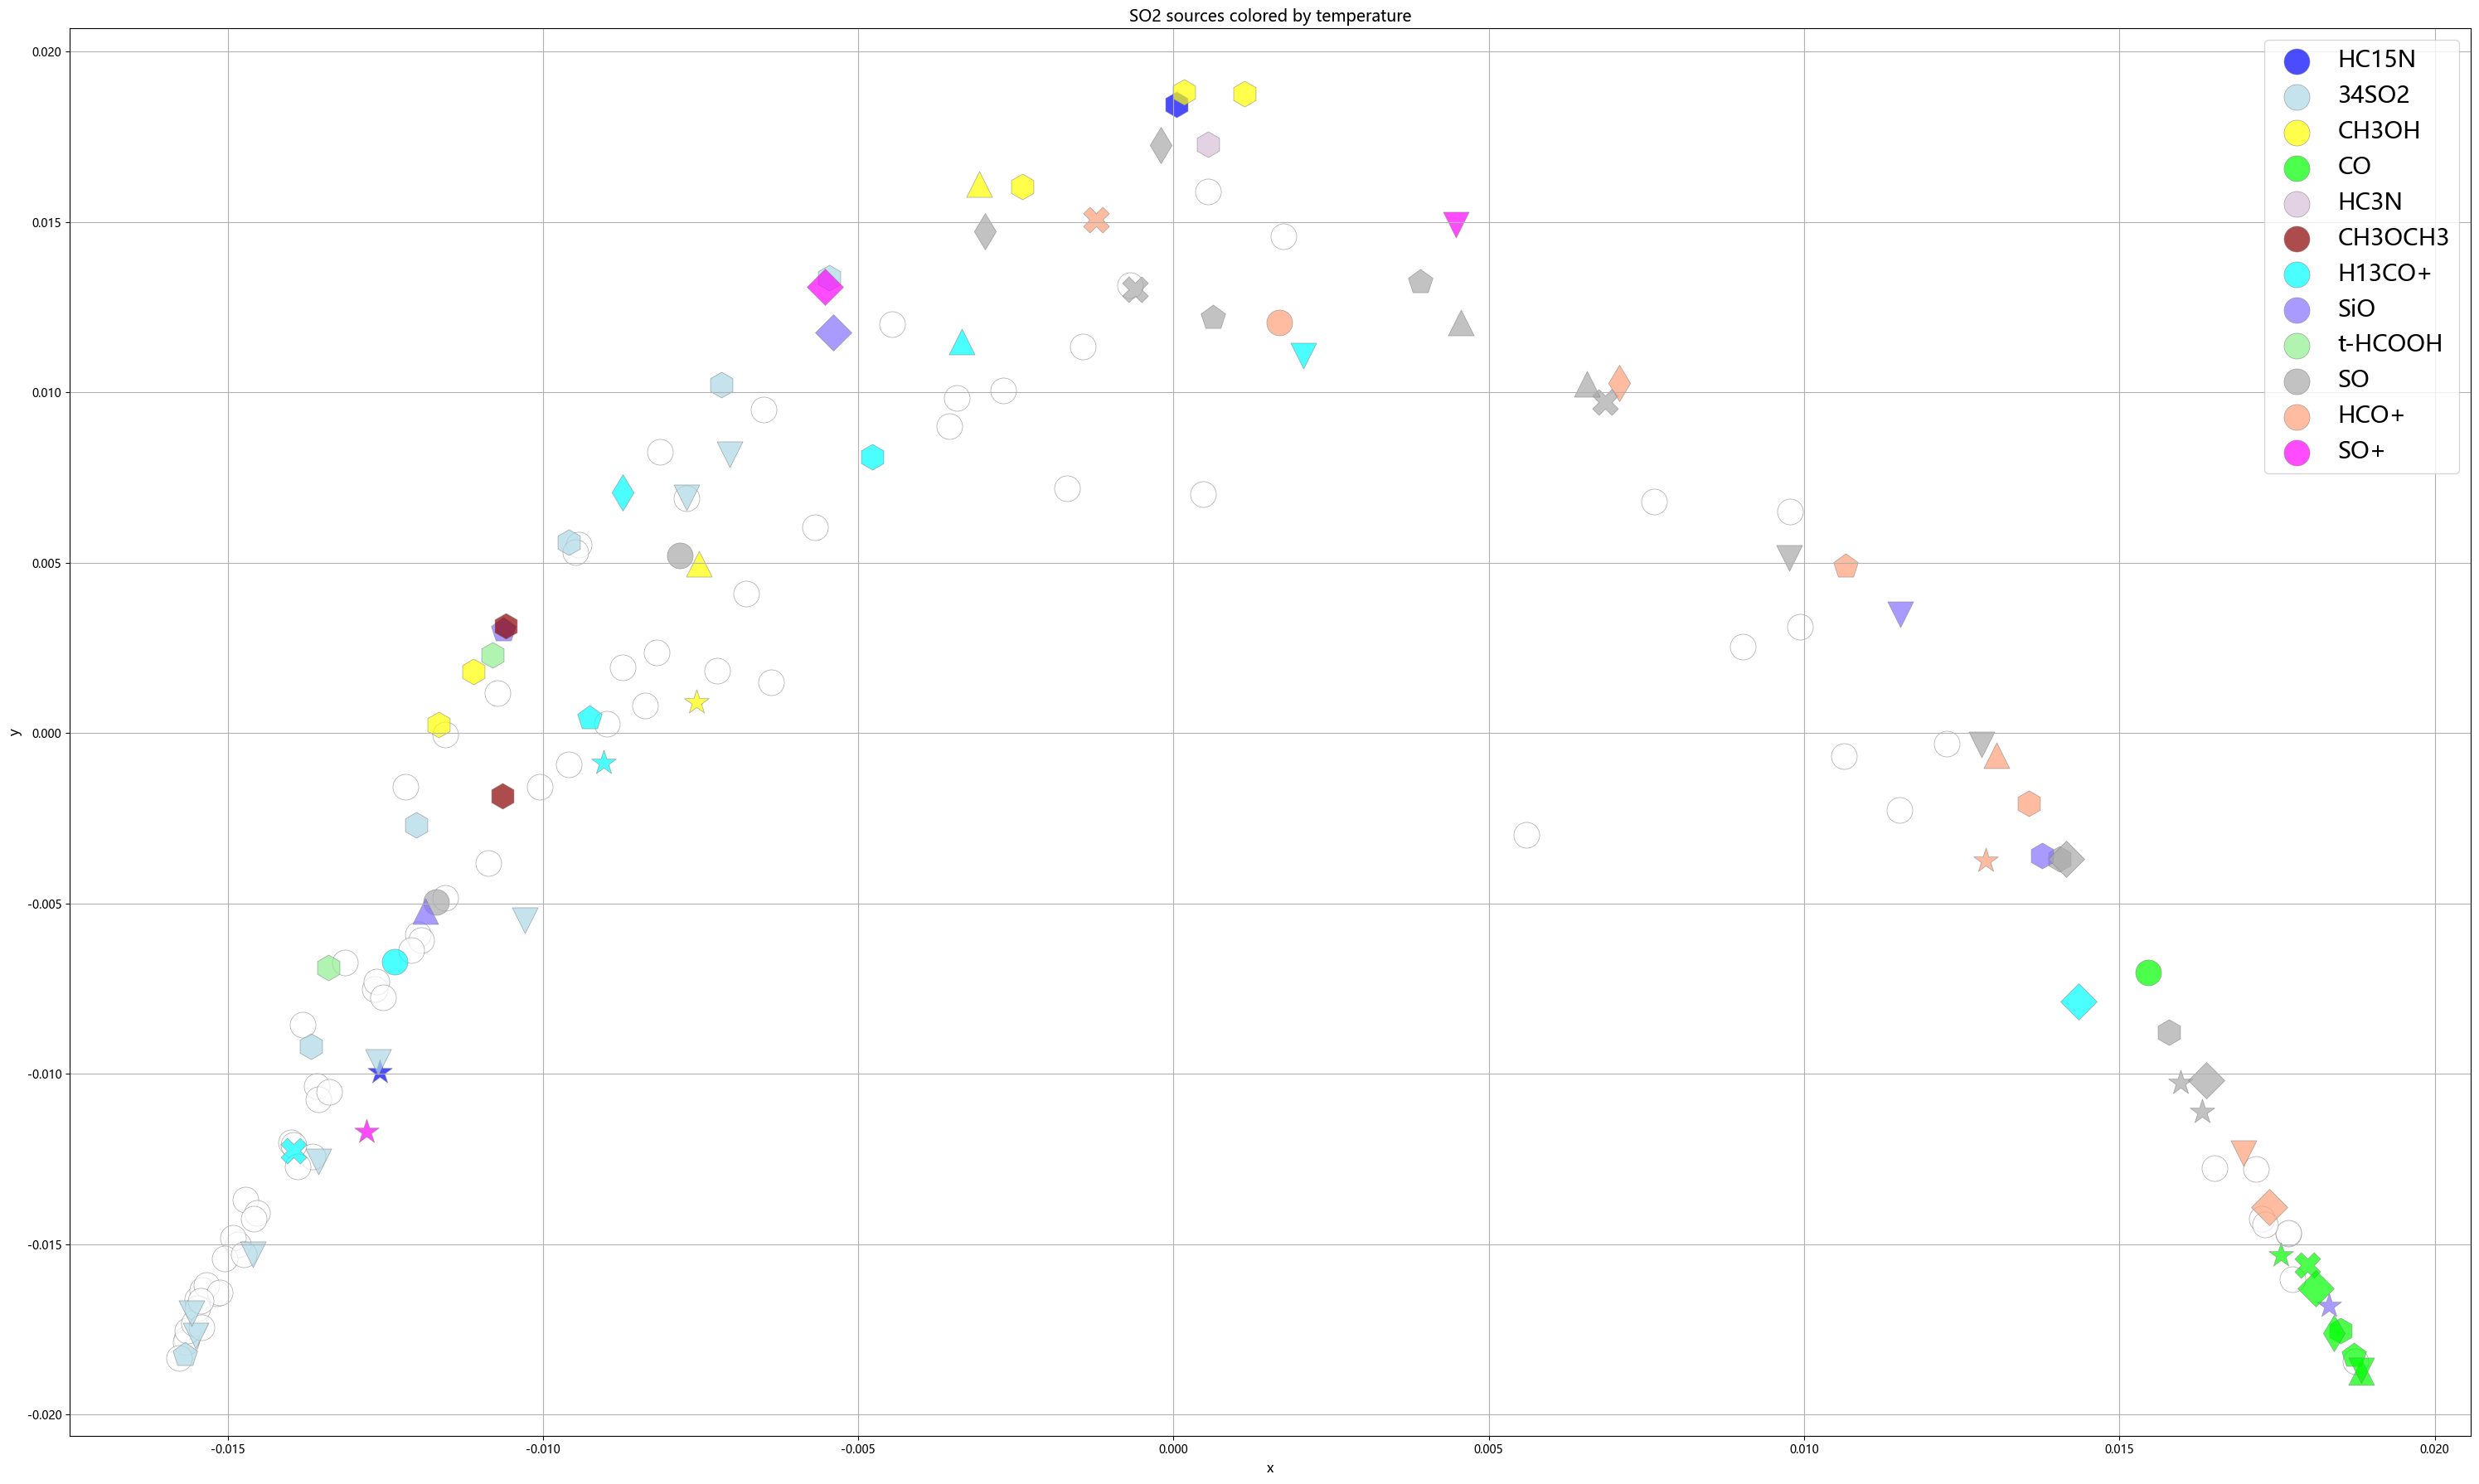

In [30]:
temperature_H2 = [sources_temperature_H2.get(src, None) for src in sources]  # 无温度则为None
temperature_SO2 = [sources_temperature_SO2.get(src, None) for src in sources]

plot_custom_scatter(
    digits_spec, sources, molecules,
    #line_strengths=source_intensity_CO,        #temperatures/luminosities/line_strengths: list of float, 连续数值  
    #evolution_sequences=source_evolution,        #evolution_sequences: list of str, 演化序列类别
    x_coord='x', y_coord='y',
    color_type='molecule',           #color_type: 着色依据，'temperature'等连续值，或'source'等离散值 
    color_category_map=color_map,    #color_category_map: 离散类别到颜色的映射字典，如 {'SO2':'red', 'H2O':'blue'}
    #continuous_cmap=plt.cm.Reds,   
                                        #continuous_missing_color: 连续数据缺失时点的颜色
                                        #marker_type: 形状依据的类别字段，如'evolution'或'source'
                                        #marker_map: 形状映射字典
    molecule_filter='not_so2',              #分子筛选，'so2'仅SO2，'not_so2'除SO2外，'all'全部
    highlight_hot_cores=True,          #highlight_hot_cores: 是否突出热核源
    hotcore_marker_map=marker_map,      #hotcore_marker_map: 热核源的形状映射，若为None且highlight_hot_cores=True，则使用marker_map
    hotcore_color='default',            #hotcore_color: 热核源的颜色，'default'表示使用正常着色规则，否则固定颜色
    non_hotcore_color='white',          #non_hotcore_color: 非热核源的统一颜色
    non_hotcore_marker='o',             #non_hotcore_marker: 非热核源的统一形状
                                        #show_legend: 是否显示图例
    annotate=False,                     #annotate: 是否标注源名称
    title='SO2 sources colored by temperature'
)

### 对比谱线

In [66]:
# 求平均谱线
def mean_spec(list7):
    mean=[]
    for i in range(len(list7[0])):  # 数据长度
        mean_data=0
        for j in range(len(list7)):   # 有几组数据
            mean_data+=list7[j][i]
        mean.append(mean_data/len(list7))
    return mean

In [83]:
def print_spec(selec_src,selec_mol,mean=True):
    indices = [i for i, (src, mol) in enumerate(zip(sources,molecules)) 
                if src == selec_src and mol == selec_mol]
    spec_tem=[]
    for i in indices:
        plt.plot(flux_matrix[i],alpha=0.8)
        spec_tem.append(flux_matrix[i])
    
    if mean==True:
        mean=mean_spec(spec_tem)
        plt.plot(mean,color='blue',linewidth=10,alpha=0.5)
    plt.title(f"{selec_mol} spectrum from {selec_src}")
    plt.show()
        

In [90]:
print_spec('Lm07','SO2')
print_spec('Lm10','SO2')

IndexError: list index out of range

### 创建子图

In [55]:
def print_picture_others(info1):
    # 创建颜色标记
    min_info=min(info1)
    max_info=max(info1)
    cmap_info = plt.cm.Blues  # 或其他 colormap
    norm_info = plt.Normalize(vmin=min_info, vmax=max_info)
    
    # 从数据中提取所有出现的分子（包括SO2）
    unique_mols = sorted(set(molecules))
    # 可以过滤SO2
    unique_mols = [m for m in unique_mols if m != 'SO2']

    
    # ---------------------------------创建子图以及设置----------------------------------------
    n_mols = len(unique_mols)
    ncols = 3  # 每行子图数量，可调整
    nrows = (n_mols + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    # 将 axes 展平为一维数组，方便索引
    axes_flat = axes.flatten() if n_mols > 1 else [axes]

    # ===== 3. 建立分子到坐标轴的映射 =====
    mol_to_ax = {mol: axes_flat[i] for i, mol in enumerate(unique_mols)}

    # 隐藏多余的坐标轴（如果子图数量多于分子数）
    for ax in axes_flat[n_mols:]:
        ax.set_visible(False)

    # -----------------------------------绘制-----------------------------------------
    for (x, y, z, k), src, mol, data1 in zip(digits_spec, sources, molecules, info1):
        # 如果该分子不在映射中则跳过
        if mol not in mol_to_ax:
            continue

        ax = mol_to_ax[mol]                     # 获取对应的坐标轴
        marker = marker_map.get(src, 'o')        # 获取标记，默认圆点

        color = color_map_sources.get(src)   # 用颜色标记源
        
        color_info1 = cmap_info(norm_info(data1))  # 用颜色标记其他信息

        ax.scatter(x, y,
                   c=color_info1,               # 注意：c需要是一个颜色值列表，即使只有一个点
                   #marker=marker,
                   s=100,
                   alpha=0.8,
                   edgecolors='grey',
                   linewidth=0.5)

        
    # ------------------------------------设置子图标题和坐标轴-------------------------------------
    for mol, ax in mol_to_ax.items():
        ax.set_title(mol)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_xlim(-0.03,0.03)


    # ===== 6. 添加全局 colorbar =====
    # 创建一个虚拟的 ScalarMappable，使用与绘图相同的 cmap 和 norm
    # sm = plt.cm.ScalarMappable(cmap=cmap_T_H2, norm=norm_T_H2)
    # sm.set_array([])  # 虚拟对象不需要数据

    # # 将 colorbar 添加到图形上，ax 参数传入所有子图，colorbar 会自动调整位置
    # cbar = fig.colorbar(sm, ax=axes_flat, label='Temperature (K)')

    plt.tight_layout()
    #plt.savefig('C:\\Users\\zyx\\Desktop\\Spectral with Machine Learning\\code\\picture\\all_sources.png', dpi=600, bbox_inches='tight')
    plt.show()

C:\Users\zyx\AppData\Local\Temp\ipykernel_1460\3768996698.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y,


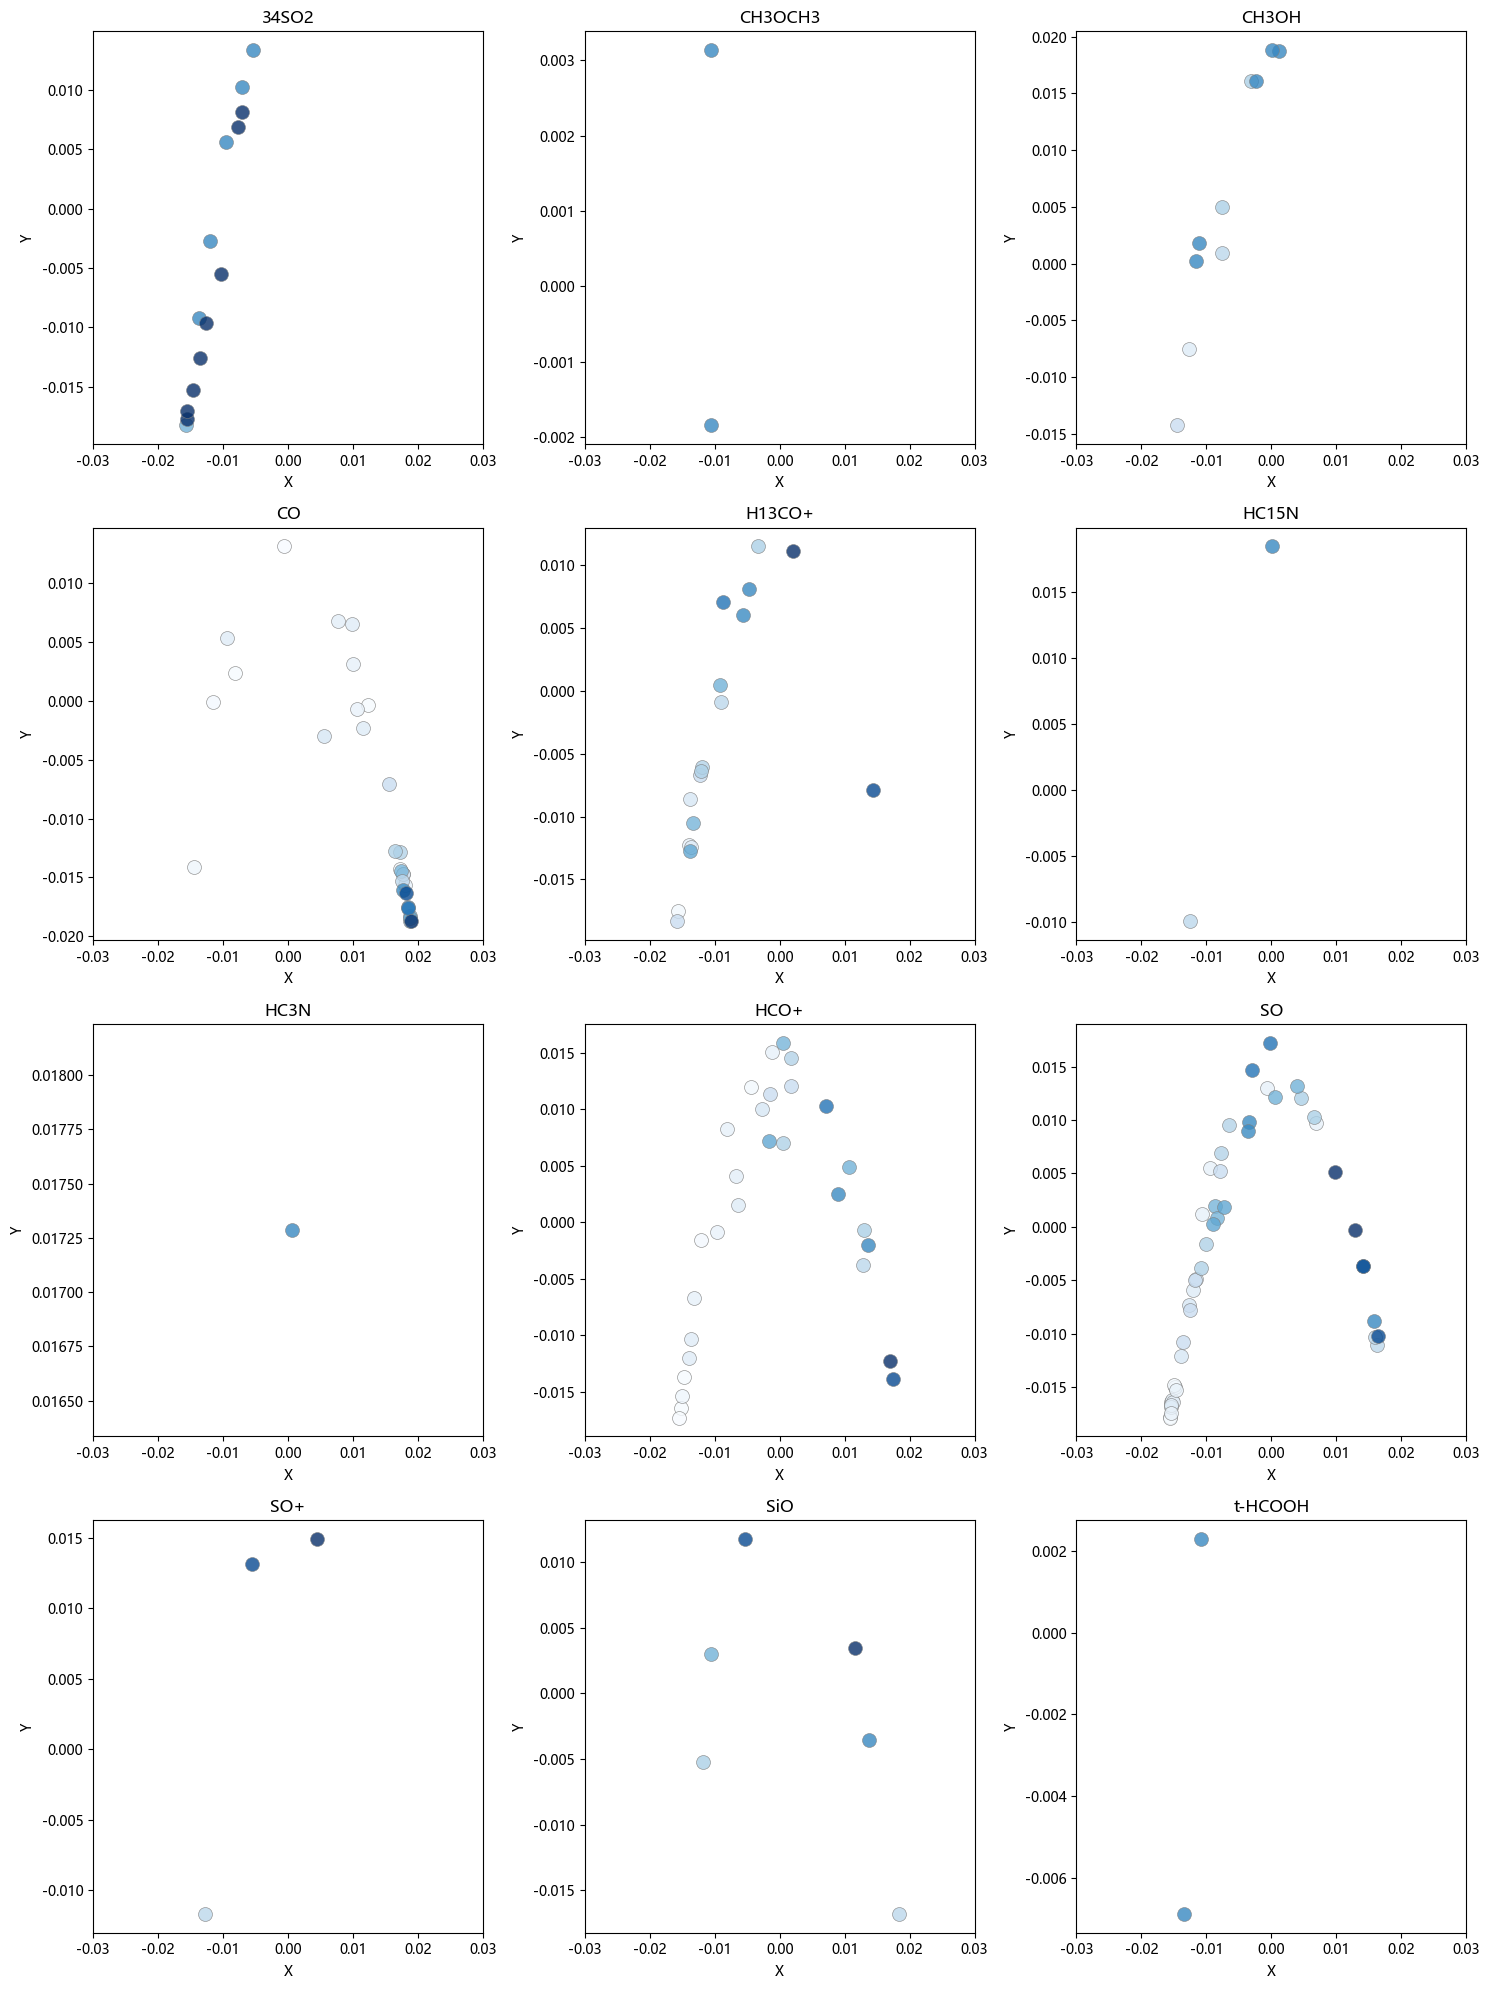

In [59]:
print_picture_others(source_luminosity)

## 计算谱线面积

In [34]:
def area(list1):
    return sum(list1)

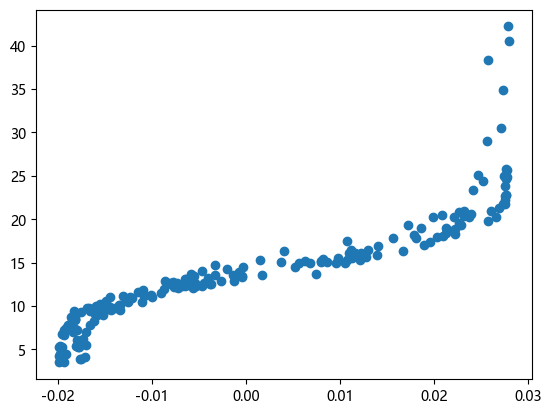

In [35]:
areas=[]
for i in range(len(flux_matrix)):
    areas.append(area(flux_matrix[i]))

# print((digits_spec[:,0]))
plt.scatter(digits_spec[:,0],areas)
plt.show()



In [36]:
def paint_spectrum(flux_matrix,list1):
    cmap = plt.cm.viridis         
    norm = plt.Normalize(vmin=min(list1), vmax=max(list1))

    plt.figure(figsize=(10, 6))
    for i in range(len(flux_matrix)):
        color = cmap(norm(list1[i]))   
        plt.plot(flux_matrix[i], color=color, alpha=0.7)  # alpha 可控制透明度，避免过度遮挡

    # 添加颜色条
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label='Color Value')

    plt.xlabel('Wavelength Index')
    plt.ylabel('Intensity')
    plt.title('200 Spectra Colored by Third List')
    plt.show()

C:\Users\zyx\AppData\Local\Temp\ipykernel_1460\3946296900.py:13: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Color Value')


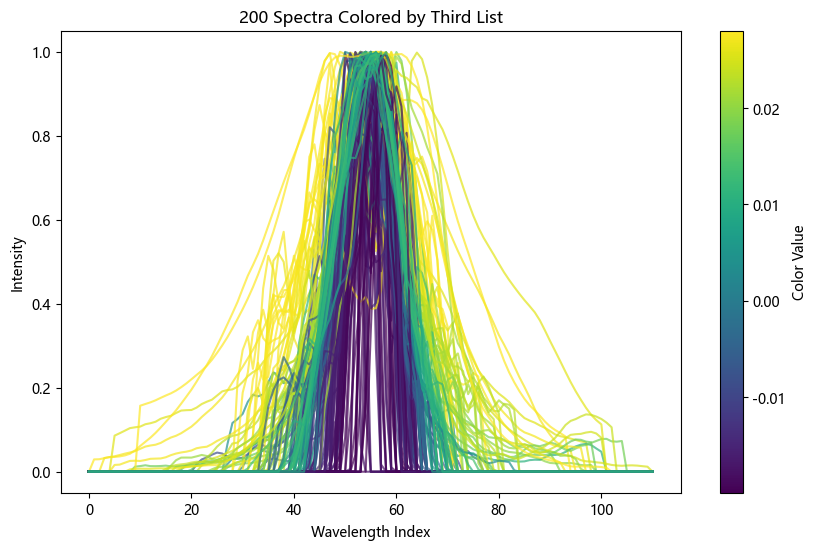

In [37]:
paint_spectrum(flux_matrix,digits_spec[:,0])

## 下面是PCA和TSNE的结果

In [ ]:
pca=PCA(n_components=2)
digits_pca=pca.fit_transform(digits_spec)

tsne=TSNE(n_components=2,perplexity=min(30, len(fluxes)-1))
digits_tsne=tsne.fit_transform(flux_matrix)

In [ ]:
#--------------------pca-----------------------------
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()

# 绘制散点 - 修正点1：移除marker和c参数的中括号
for (x, y), src, mol in zip(digits_pca, sources, molecules):
    if mol!='SO2':
        color = color_map.get(mol, '#808080')  # 默认灰色
        marker = marker_map.get(src, 'o')  # 添加默认值
        # 注意：这里移除了marker=[marker]和c=[color]中的中括号
        plt.scatter(x, y, c=color, 
                    marker=marker, s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)

# 添加图例
legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
                    loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
                    handleheight=1.5, title_fontsize=18, fontsize=18)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_elements_src, title='源', 
                    loc='upper left', bbox_to_anchor=(1.02, 0.55), handlelength=5,
                    handleheight=5, title_fontsize=18, fontsize=18, 
                    labelspacing=0, markerscale=2.0)


#---------------------------tsne---------------------------------

fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()

# 绘制散点
for (x, y), src, mol in zip(digits_tsne, sources, molecules):
    if mol!='SO2':
        color = color_map.get(mol, '#808080')  # 默认灰色
        marker = marker_map.get(src, 'o')  # 添加默认值
        # 注意：这里移除了marker=[marker]和c=[color]中的中括号
        plt.scatter(x, y, c=color, marker=marker, s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)

# 添加图例
legend1 = ax.legend(handles=legend_elements_mol, title='分子', 
                    loc='upper left', bbox_to_anchor=(1.02, 1), handlelength=3,
                    handleheight=1.5, title_fontsize=18, fontsize=18)
ax.add_artist(legend1)

legend2 = ax.legend(handles=legend_elements_src, title='源', 
                    loc='upper left', bbox_to_anchor=(1.02, 0.55), handlelength=5,
                    handleheight=5, title_fontsize=18, fontsize=18, 
                    labelspacing=0, markerscale=2.0)

In [ ]:
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()
plt.scatter(digits_pca[:, 0], digits_pca[:, 1], 
            c=labels, cmap='Set1',s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Spectral Embedding projection with Spectral Clustering labels')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(30, 18))
ax.grid()
plt.scatter(digits_tsne[:, 0], digits_tsne[:, 1], 
            c=labels, cmap='Set1',s=400, alpha=0.8, 
                    edgecolors='grey', linewidth=0.5)
plt.colorbar(label='Cluster Label')
plt.title('Spectral Embedding projection with Spectral Clustering labels')
plt.show()